# Poster figures — cell-type specificity, data efficiency, and what it costs

Consolidates `comparing_model4`, `comparing_model5`, `eQTL_benchmark5`, `dsQTL_benchmark7`
and `EP_linking9` into the six panels the poster needs. Runs top-to-bottom on a cold kernel.

**The one claim.** Multitask training buys generality at the cost of cell-type specificity,
and you cannot buy the specificity back by retraining. Taking accessibility as an input gets
it back — with 2 training tracks instead of >5,000.

| panel | question | source |
|---|---|---|
| **A** | On promoters where generic expression and GM12878 truth disagree, which does the model follow? | `comparing_model4` §20, `comparing_model5` §12 |
| **B** | Is training breadth a dial that trades specificity against sensitivity? | §20 + eQTL, recomputed here |
| **C** | Does adapting Borzoi to GM12878 close the gap? | `comparing_model5` §12 |
| **D** | Does the sequence channel still work? (eQTL: accessibility held fixed) | recomputed here from raw ref/alt arrays |
| **E** | Same question on chromatin QTLs | recomputed here |
| **F** | The control: does the model beat its own accessibility input? | `comparing_model4` §20b, `comparing_model5` §12b |

**Two conventions are enforced throughout, and both matter.**

1. **Average precision, never `auc(recall, precision)`.** The trapezoid interpolates across
   tied scores and hands a model that cannot see a variant ~(chance+1)/2 for free. On the
   >100 kb E–G stratum that turns pretrained Enformer's *zero* reachable positives into a
   reported 0.505. Every number below is `average_precision_score`.
2. **Common support.** A model is only compared where the variant fell inside the sequence it
   was shown. Enformer reaches ±98 kb, everything else ±262 kb or more; scoring out-of-window
   rows as 0.0 ranks them last, which is free accuracy on a mostly-negative distal bin.

Enhancer–gene linking is deliberately **not** a panel here — see the closing section.

## 0. Setup and palette

In [1]:
# ============================================================================
# POSTER FIGURES - shared setup, palette, and the results block
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

FIGDIR = '/data1/lesliec/sarthak/caduceus/code_test/poster_figs'
os.makedirs(FIGDIR, exist_ok=True)

# --- palette -----------------------------------------------------------------
# Four family hues, fixed order, never cycled. Validated with the dataviz
# six-checks validator (light mode, ALL pairs): lightness band PASS, chroma
# floor PASS, CVD separation worst dE 9.2 PASS, normal-vision floor worst
# dE 16.3 PASS, contrast WARN on OURS_G only -> every bar carries an axis
# name and a printed value, so identity never rests on colour.
C_OURS = '#2a78d6'   # cis-Mamba (this work)
C_ENF  = '#eb6834'   # Enformer family
C_BOR  = '#1baf7a'   # Borzoi family
C_AG   = '#4a3aa7'   # AlphaGenome
C_REF  = '#6b7280'   # measurements / null / chance -- never a model

FAMILY = {'ours': C_OURS, 'enformer': C_ENF, 'borzoi': C_BOR,
          'alphagenome': C_AG, 'reference': C_REF}

mpl.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12.5,
    'xtick.labelsize': 10.5, 'ytick.labelsize': 10.5, 'legend.fontsize': 10.5,
    'figure.dpi': 110, 'savefig.dpi': 300, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.linewidth': 0.9,
    'axes.edgecolor': '#444444', 'text.color': '#222222',
    'axes.labelcolor': '#222222', 'xtick.color': '#444444',
    'ytick.color': '#444444', 'figure.facecolor': 'white',
})
INK, INK2 = '#222222', '#555555'


def tidy(ax, grid='y'):
    """Recessive grid behind the marks, no tick spurs on the categorical axis."""
    ax.grid(axis=grid, ls='--', lw=0.55, color='#CCCCCC', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x' if grid == 'y' else 'y', length=0)
    return ax


def barh_labeled(ax, labels, values, colors, fmt='{:.3f}', pad=0.008,
                 err=None, xmax=None):
    """Horizontal bars, best at top, value printed at the end of each bar."""
    y = np.arange(len(labels))
    ax.barh(y, values, height=0.68, color=colors, zorder=3,
            xerr=err, error_kw=dict(ecolor='#666666', lw=1.1, capsize=2.5))
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    span = (xmax or max(values)) 
    for yi, v in enumerate(values):
        off = (err[1][yi] if err is not None else 0) + pad * span
        ax.text(v + off, yi, fmt.format(v), va='center', ha='left',
                fontsize=9.5, color=INK2)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    return ax

## 0b. The results block

Every hardcoded number, with the notebook and section it was read from. Panels D and E are
recomputed from the raw prediction arrays further down and appear nowhere in this block.

In [2]:
# ============================================================================
# THE RESULTS BLOCK - every number, with the notebook + section it came from.
# Panels D and E are recomputed live further down; everything here is read off
# a gated table in the source notebook rather than re-derived.
# ============================================================================
import pandas as pd

# --- Panel A / C / F : cell-type specificity ---------------------------------
# comparing_model4.ipynb  §20  (Enformer grid, 128 bp bins, 1883 allowed regions,
#   464 positives / 419 negatives; ATAC-open contrast; 200-boot 95% CI)
#   AUROC anchors: 1.0 = perfectly cell-type-specific, 0.5 = no cell-type
#   information, 0.0 = the output IS the cross-cell-type average.
SPEC_ENF_GRID = pd.DataFrame([
    #  label,                             family,        auroc,  lo,     hi,    fp,    rec,   index, n_ct
    ('cis-Mamba (1 cell type)',           'ours',        0.779, 0.739, 0.814, 0.181, 0.528, -0.049,   1),
    ('cis-Mamba, no pretraining',         'ours',        0.727, 0.681, 0.765, 0.148, 0.459, -0.105,   1),
    ('cis-Mamba (8 cell types)',          'ours',        0.568, 0.520, 0.614, 0.368, 0.466, -0.195,   8),
    ('Enformer (pretrained)',             'enformer',    0.484, 0.426, 0.545, 0.401, 0.349, -0.241, 800),
    ('Enformer retrained, 1 CT (1536ch)', 'enformer',    0.425, 0.372, 0.487, 0.470, 0.358, -0.256,   1),
    ('AlphaGenome',                       'alphagenome', 0.408, 0.350, 0.457, 0.683, 0.601,  0.028, 800),
    ('Enformer retrained, 1 CT',          'enformer',    0.355, 0.294, 0.414, 0.585, 0.384, -0.274,   1),
    ('Enformer retrained, 16 CTs',        'enformer',    0.319, 0.268, 0.370, 0.621, 0.336, -0.331,  16),
    ('Enformer retrained, 42 CTs',        'enformer',    0.267, 0.224, 0.312, 0.721, 0.360, -0.348,  42),
    ('[null] cross-cell-type average',    'reference',   0.000, 0.000, 0.000, 1.000, 0.000, -1.000,  -1),
], columns=['label', 'family', 'auroc', 'lo', 'hi', 'fp', 'recall', 'index', 'n_ct'])

# comparing_model5.ipynb  §12  (Borzoi fold3 grid, 32 bp bins, 6797 allowed
#   regions, 2848 positives / 12294 negatives; DNase-open contrast)
SPEC_BOR_GRID = pd.DataFrame([
    #  label,                             family,        auroc,  lo,     hi,   r_true,  fp,    rec,   n_ct
    ('cis-Mamba (ep4)',                   'ours',        0.626, 0.609, 0.644, 0.6221, 0.420, 0.621,   1),
    ('cis-Mamba (ep10)',                  'ours',        0.578, 0.561, 0.595, 0.6340, 0.401, 0.492,   1),
    ('Borzoi full FT (GM12878)',          'borzoi',      0.462, 0.442, 0.484, 0.6582, 0.458, 0.400,   1),
    ('Borzoi from scratch (GM12878)',     'borzoi',      0.436, 0.414, 0.456, 0.6052, 0.565, 0.518,   1),
    ('Borzoi LoRA (GM12878)',             'borzoi',      0.395, 0.378, 0.418, 0.6367, 0.603, 0.485,   1),
    ('AlphaGenome',                       'alphagenome', 0.348, 0.322, 0.375, 0.4206, 0.860, 0.736, 800),
    ('Borzoi (pretrained)',               'borzoi',      0.177, 0.165, 0.190, 0.6182, 0.853, 0.412, 800),
    ('[null] cross-cell-type average',    'reference',   0.000, 0.000, 0.000, np.nan, 1.000, 0.000,  -1),
], columns=['label', 'family', 'auroc', 'lo', 'hi', 'r_true', 'fp', 'recall', 'n_ct'])
# r_true  = median per-region smoothed-log Pearson vs GM12878 CAGE (comparing_model5 §10)
# fp/rec  = at each arm's OWN p95 over allowed bins, so the background call rate is 5%
#           for every arm by construction (comparing_model5 §12). 2,848 pos / 12,294 neg.
# AlphaGenome's r_true is NOT comparable -- it predicts in its own units (5.2x the target's
# total signal, not Borzoi squashed counts), so it is excluded from the accuracy panel.
# Its AUROC / fp / recall are rank-based and therefore safe.

# --- Panel F : the same contrast with accessibility REMOVED from the labels
# and scored as a method (comparing_model4 §20b / comparing_model5 §12b).
# This is the control that decides whether the model beats its own input.
ACC_ENF_GRID = pd.DataFrame([
    ('GM12878 ATAC (measured)',           'reference',   0.556, 0.511, 0.593),
    ('cis-Mamba (1 cell type)',           'ours',        0.538, 0.492, 0.580),
    ('cis-Mamba, no pretraining',         'ours',        0.494, 0.445, 0.536),
    ('Enformer (pretrained)',             'enformer',    0.355, 0.312, 0.399),
    ('cis-Mamba (8 cell types)',          'ours',        0.337, 0.295, 0.377),
    ('Enformer retrained, 1 CT (1536ch)', 'enformer',    0.295, 0.253, 0.339),
    ('Enformer retrained, 1 CT',          'enformer',    0.236, 0.195, 0.281),
    ('AlphaGenome',                       'alphagenome', 0.221, 0.185, 0.255),
    ('Enformer retrained, 16 CTs',        'enformer',    0.209, 0.178, 0.249),
    ('Enformer retrained, 42 CTs',        'enformer',    0.166, 0.130, 0.205),
], columns=['label', 'family', 'auroc', 'lo', 'hi'])

ACC_BOR_GRID = pd.DataFrame([
    ('GM12878 DNase (measured)',          'reference',   0.389, 0.374, 0.404),
    ('cis-Mamba (ep4)',                   'ours',        0.354, 0.340, 0.366),
    ('cis-Mamba (ep10)',                  'ours',        0.329, 0.316, 0.340),
    ('Borzoi full FT (GM12878)',          'borzoi',      0.300, 0.287, 0.315),
    ('Borzoi from scratch (GM12878)',     'borzoi',      0.238, 0.227, 0.250),
    ('Borzoi LoRA (GM12878)',             'borzoi',      0.231, 0.218, 0.245),
    ('AlphaGenome',                       'alphagenome', 0.179, 0.166, 0.194),
    ('Borzoi (pretrained)',               'borzoi',      0.092, 0.084, 0.100),
], columns=['label', 'family', 'auroc', 'lo', 'hi'])

# --- design-free companion: partial correlations, no labels/thresholds/ATAC ---
# index = r(pred,TRUE|AVG) - r(pred,AVG|TRUE);  <0 -> explains the cross-cell-type
# average better than it explains GM12878.  (comparing_model4 §20 metric 2)
# design-free companion, carried on SPEC_ENF_GRID so the two can never disagree
PARTIAL_ENF = SPEC_ENF_GRID[SPEC_ENF_GRID.family != 'reference'][
    ['label', 'family', 'index']].reset_index(drop=True)

# --- training scale, for the data-efficiency framing --------------------------
TRACK_COUNTS = {
    'Enformer':    5313,   # human output tracks
    'Borzoi':      7611,   # human output tracks
    'AlphaGenome': None,   # multi-modal, multi-species; not directly comparable
    'cis-Mamba (1 CT)':  2,   # 1 DNase + 1 CAGE
    'cis-Mamba (8 CTs)': 16,  # 8 DNase + 8 CAGE
}

---
## Panel A, part 1 — the Enformer grid, recomputed live

`comparing_model4` §20 ported here so the **pretraining ablation** can be added as a ninth
arm. This overwrites the hardcoded `SPEC_ENF_GRID` from the results block above; the Borzoi
grid stays hardcoded.

`nopretrain_predictions.npy` is the CAGE finetune run with
`train.pretrained_model_path = None` — `outputs/2025-04-21/15-40-14-845019` (ID 51). Against
the reference CAGE finetune (ID 63, `outputs/2025-05-08/16-33-43-098345`) the only
substantive config difference is that one field; the rest is `num_workers` and an eval flag.
It keeps the accessibility input, so it isolates the **masked-accessibility pretraining
stage** and nothing else.

> **Caveat to check before quoting.** ID 51 resumes from ID 47
> (`outputs/2025-04-14/18-36-09-021037`), which additionally carries `decoder.mode = pool`,
> a setting neither ID 51 nor the reference has. Confirm which of the two actually wrote
> `nopretrain_predictions.npy`.

**What it says — and the two components turn out to do different jobs.**

| | specificity AUROC | distal eQTL AUPRC | proximal eQTL |
|---|---|---|---|
| cis-Mamba (1 CT) | 0.779 | 0.402 | 0.607 |
| cis-Mamba, no pretraining | 0.727 | **0.337** | **0.543** |
| Enformer retrained, 1 CT | 0.355 | 0.408 | 0.658 |

* **The accessibility input buys cell-type specificity.** Removing the pretraining costs
  0.779 → 0.727 with overlapping CIs; removing the accessibility input — approximated by
  Enformer retrained on the same single cell type — costs 0.779 → 0.355. On this metric the
  input accounts for essentially the whole gap.
* **The pretraining buys variant-effect sensitivity.** Without it the model is the *worst*
  arm in every eQTL distance bin (0.337 distal, 0.378 flanking, 0.543 proximal), well below
  the pretrained version and below every Borzoi and Enformer arm. That is mechanistically
  what you would expect: the pretraining task *is* sequence → accessibility, which is the
  function you differentiate when you score a variant.

So the two design choices are not redundant, and neither subsumes the other. Say it that
way: **accessibility as an input is what makes the model cell-type-specific; the masked
accessibility pretraining is what makes it able to read sequence variants** — and it is also
what keeps expression out of the pretraining objective, which is the leakage answer.

Do **not** claim the pretraining is load-bearing for *specificity* — on that metric it adds
little. Do claim it for variant effects.

The matched no-accessibility-input arm (`outputs/2025-04-28/15-21-24-283130`, ID 55,
`acc_mlm 0.25 → 1`) has no CAGE finetune yet, so it cannot go on this panel without training
that stage with `acc_mlm=1`. That is the paper version of this row.

In [3]:
# ============================================================================
# Enformer-grid cell-type specificity, recomputed live, with the PRETRAINING
# ABLATION added as a ninth arm.  Ported from comparing_model4 §20; the only
# change is the extra `nopretrain` entry in SPEC and the arm->family mapping.
#
# Scale anchors: 1.0 = perfectly cell-type-specific, 0.5 = no cell-type
# information, 0.0 = the prediction IS the cross-cell-type average.
# ============================================================================
# Set True to rebuild the two Enformer-grid tables from the zarr/npy instead of
# using the values in the results block. Takes ~10 min (2 x 300 bootstraps x 10 arms);
# the hardcoded values ARE this cell's output, so leave it False unless an arm changes.
RECOMPUTE_SPEC = False

if RECOMPUTE_SPEC:
    import os, sys
    import numpy as np
    import pandas as pd
    import zarr

    sys.path.insert(0, '/data1/lesliec/sarthak/caduceus')
    from evals.plotting_utils import GeneAnnotation

    DATA = '/data1/lesliec/sarthak/data'
    S_MO = f'{DATA}/joint_playground/model_out'
    S_BIN, S_T, S_TRACK, S_CAGE_START = 128, 896, 5110, 4675
    S_CROP = (131072 - S_T * S_BIN) // 2
    S_CTX, S_OVF = 524288, 0.20
    S_ACTIVE, S_SILENT, S_TSSPAD = 1.0, 0.2, 500     # comparing_model4 §2.5 noise floor

    # label, loader key, run stem, family
    SPEC = [
        ('cis-Mamba (1 cell type)',           'mamba',       None, 'ours'),
        ('cis-Mamba, no pretraining',         'nopretrain',  None, 'ours'),      # <-- the ablation
        ('cis-Mamba (8 cell types)',          'immune',      None, 'ours'),
        ('Enformer (pretrained)',             'enformer',    None, 'enformer'),
        ('AlphaGenome',                       'alphagenome', None, 'alphagenome'),
        ('Enformer retrained, 1 CT',          'enformer_retrained_gm12878',
                                              'enformer_retrained_gm12878', 'enformer'),
        ('Enformer retrained, 1 CT (1536ch)', 'enformer_retrained_n1_1536',
                                              'enformer_retrained_n1_1536', 'enformer'),
        ('Enformer retrained, 16 CTs',        'enformer_retrained_n16',
                                              'enformer_retrained_n16', 'enformer'),
        ('Enformer retrained, 42 CTs',        'enformer_retrained_n42',
                                              'enformer_retrained_n42', 'enformer'),
    ]

    S_TRUE = np.load(f'{S_MO}/GM12878_base_targets_conv.npy').astype(np.float32)
    S_P, S_FAM = {}, {}
    for label, key, stem, fam in SPEC:
        if key == 'enformer':
            arr = np.load(f'{S_MO}/enformer_test_track{S_TRACK}.npy').astype(np.float32)
        elif key == 'alphagenome':
            arr = np.asarray(np.load(f'{S_MO}/alphagenome_cage_test_128bp.npy',
                                     mmap_mode='r')[:, :, 156], dtype=np.float32)
        elif key in ('mamba', 'immune', 'nopretrain'):
            f = {'mamba': 'GM12878_no_mlm', 'immune': 'immune_CAGE',
                 'nopretrain': 'nopretrain'}[key]
            _p = np.load(f'{S_MO}/{f}_predictions.npy')
            arr = (_p[:, :, 0] if _p.ndim == 3 else _p).astype(np.float32)
            _t = np.load(f'{S_MO}/{f}_targets.npy')
            _t = _t[:, :, 0] if _t.ndim == 3 else _t
            assert np.allclose(np.asarray(_t, np.float32), S_TRUE, rtol=1e-5, atol=1e-6), \
                f'GATE FAILED [{label}]: its target is not the GM12878 reference target'
        else:
            d = f'{S_MO}/{key}'
            pr = np.load(f'{d}/{stem}_cage_predictions.npy', mmap_mode='r')
            tg = np.load(f'{d}/{stem}_cage_targets.npy', mmap_mode='r')
            if pr.ndim == 3:
                tr = pd.read_csv(f'{d}/{stem}_cage_tracks.csv')
                row = tr[(tr['cell_type'] == 'GM12878') & (tr['assay'] == 'cage')]
                assert len(row) == 1 and int(row['target_index'].iloc[0]) == S_TRACK
                col = int(row['column'].iloc[0]); pr, tg = pr[:, :, col], tg[:, :, col]
            assert np.allclose(np.asarray(tg), S_TRUE, rtol=1e-5, atol=1e-6), \
                f'GATE FAILED [{label}]'
            arr = np.ascontiguousarray(pr, dtype=np.float32)
        assert arr.shape == S_TRUE.shape
        S_P[label], S_FAM[label] = arr, fam
    print(f'{len(S_P)} models loaded, all target-gated')

    _lab = zarr.open(f'{DATA}/enformer/data/labels.zarr', mode='r')['test']
    _n_cage = _lab.shape[2] - S_CAGE_START
    _gm = np.asarray(_lab[:, :, S_TRACK], dtype=np.float32)
    assert np.array_equal(_gm, S_TRUE)
    S_AVGALL = np.load(f'{DATA}/enformer/data/avg_cage_test_all.npy')
    S_AVG = np.clip((S_AVGALL * _n_cage - _gm) / (_n_cage - 1), 0, None)
    S_ATAC = np.load(f'{DATA}/enformer/data/GM12878_ATAC_WW_denoised.npz')['test'][:, :, 0]
    print(f'AVG over {_n_cage} CAGE experiments, GM12878 removed; ATAC on the same grid')

    _bed = pd.read_csv(f'{DATA}/DK_zarr/sequences_enformer.bed', sep='\t', header=None,
                       dtype={0: str})
    _sc = _bed.shape[1] - 1
    S_TB = _bed[_bed[_sc] == 'test'].reset_index(drop=True)
    _tr = {}
    for _ch, _g in _bed[_bed[_sc] == 'train'].groupby(0):
        _ce = (_g[1].astype(int).to_numpy() + _g[2].astype(int).to_numpy()) // 2
        _tr[str(_ch)] = (_ce - S_CTX // 2, _ce + S_CTX // 2)
    _bl = np.zeros(len(S_TB), bool)
    for _i in range(len(S_TB)):
        _ch = str(S_TB.iloc[_i, 0]); _c, _d = int(S_TB.iloc[_i, 1]), int(S_TB.iloc[_i, 2])
        if _ch in _tr:
            _a, _b = _tr[_ch]
            if np.any(np.maximum(0, np.minimum(_b, _d) - np.maximum(_a, _c)) > S_OVF * (_d - _c)):
                _bl[_i] = True
    S_ALLOWED = ~_bl

    _txs = GeneAnnotation().df
    _txs = _txs[_txs['feature'] == 'transcript']
    _tssd = {}
    for _ch, _g in _txs.groupby('chrom'):
        _p = np.where(_g['strand'].to_numpy() == '+', _g['start0'].to_numpy(), _g['end0'].to_numpy())
        _tssd[str(_ch)] = np.sort(_p)
    _ctr = (S_TB.iloc[:, 1].to_numpy().astype(np.int64) + S_CROP)[:, None] \
        + np.arange(S_T)[None, :] * S_BIN + S_BIN // 2
    _chr = S_TB.iloc[:, 0].to_numpy().astype(str)
    S_TSS = np.zeros((len(S_TB), S_T), bool)
    for _ch in np.unique(_chr):
        _arr = _tssd.get(_ch)
        if _arr is None or _arr.size == 0: continue
        _rows = np.flatnonzero(_chr == _ch); _c = _ctr[_rows]
        _i = np.searchsorted(_arr, _c)
        _lo = _arr[np.clip(_i - 1, 0, _arr.size - 1)]
        _hi = _arr[np.clip(_i, 0, _arr.size - 1)]
        S_TSS[_rows] = np.minimum(np.abs(_c - _lo), np.abs(_c - _hi)) <= S_TSSPAD
    print(f'{S_ALLOWED.sum()} allowed regions; {S_TSS[S_ALLOWED].mean():.2%} of allowed bins near a pc TSS')

    S_A = np.repeat(S_ALLOWED, S_T)
    S_RID = np.repeat(np.arange(len(S_TB)), S_T)
    _tv, _av, _ac, _ts = S_TRUE.ravel(), S_AVG.ravel(), S_ATAC.ravel(), S_TSS.ravel()
    S_OPEN = float(np.percentile(_ac[S_A], 95))
    _hi_avg = _av >= np.percentile(_av[S_A & _ts], 90)
    _lo_avg = _av < np.percentile(_av[S_A & _ts], 50)
    S_POS = S_A & _ts & _lo_avg & (_tv >= S_ACTIVE) & (_ac >= S_OPEN)
    S_NEG = S_A & _ts & _hi_avg & (_tv < S_SILENT) & (_ac < S_OPEN)
    print(f'positives {S_POS.sum():,} / negatives {S_NEG.sum():,}')

    def s_auroc(pos, neg):
        a = np.concatenate([pos, neg]); r = pd.Series(a).rank().to_numpy()
        n1, n0 = len(pos), len(neg)
        return (r[:n1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

    def s_group(mask):
        idx = np.flatnonzero(mask); r = S_RID[idx]
        o = np.argsort(r, kind='stable'); idx, r = idx[o], r[o]
        regs, starts = np.unique(r, return_index=True)
        return idx, list(zip(starts, np.append(starts[1:], len(idx)))), regs

    S_PI, S_PS, S_PR = s_group(S_POS)
    S_NI, S_NS, S_NR = s_group(S_NEG)
    S_RNG = np.random.default_rng(0)
    def s_draw(v, idx, sl, regs):
        pick = S_RNG.integers(0, len(regs), len(regs))
        return np.concatenate([v[idx[sl[k][0]:sl[k][1]]] for k in pick])

    _L = lambda x: np.log1p(np.clip(x, 0, None))
    S_SUB = S_A & (_tv >= S_ACTIVE)
    _yt, _ya = _L(_tv[S_SUB]), _L(_av[S_SUB])
    S_RTA = float(np.corrcoef(_yt, _ya)[0, 1])
    print(f'r(TRUE, AVG_LOO) = {S_RTA:.3f}\n')

    rows = []
    for label in list(S_P) + ['[null] cross-cell-type average']:
        pv = S_AVG.ravel() if label.startswith('[null]') else S_P[label].ravel()
        a0 = s_auroc(pv[S_PI], pv[S_NI])
        bo = [s_auroc(s_draw(pv, S_PI, S_PS, S_PR), s_draw(pv, S_NI, S_NS, S_NR)) for _ in range(300)]
        lo, hi = np.percentile(bo, [2.5, 97.5])
        yp = _L(pv[S_SUB])
        r_pt = float(np.corrcoef(yp, _yt)[0, 1]); r_pa = float(np.corrcoef(yp, _ya)[0, 1])
        d1 = np.sqrt(max((1 - r_pa ** 2) * (1 - S_RTA ** 2), 1e-12))
        d2 = np.sqrt(max((1 - r_pt ** 2) * (1 - S_RTA ** 2), 1e-12))
        pt_a, pa_t = (r_pt - r_pa * S_RTA) / d1, (r_pa - r_pt * S_RTA) / d2
        thr = float(np.percentile(pv[S_A], 95))
        rows.append(dict(label=label, family=S_FAM.get(label, 'reference'), auroc=a0, lo=lo, hi=hi,
                         fp=np.mean(pv[S_NI] >= thr), recall=np.mean(pv[S_PI] >= thr),
                         index=pt_a - pa_t))

    SPEC_ENF_GRID = pd.DataFrame(rows).sort_values('auroc', ascending=False).reset_index(drop=True)
    print('METRIC 1 - specificity contrast  |  1.0 = specific, 0.5 = no info, 0.0 = pure average')
    print(f"{'arm':<34}{'AUROC':>8}{'95% CI':>20}{'FP@silent':>11}{'recall@active':>15}")
    for _, r in SPEC_ENF_GRID.iterrows():
        print(f"{r.label:<34}{r.auroc:>8.3f}{'[{:.3f}, {:.3f}]'.format(r.lo, r.hi):>20}"
              f"{r.fp:>11.1%}{r.recall:>15.1%}")


    # ============================================================================
    # §20b on the same grid: accessibility REMOVED from the label definition and
    # scored as a method. Same arms plus measured ATAC. This is the control that
    # decides whether a model beats its own input, so the ablation belongs in it.
    # ============================================================================
    A_POS = S_A & _ts & _lo_avg & (_tv >= S_ACTIVE)          # no open/closed condition
    A_NEG = S_A & _ts & _hi_avg & (_tv < S_SILENT)
    A_PI, A_PS, A_PR = s_group(A_POS)
    A_NI, A_NS, A_NR = s_group(A_NEG)
    print(f'\n§20b classes -- positives {A_POS.sum():,} / negatives {A_NEG.sum():,}')
    print(f'   ATAC-open rate: positives {np.mean(_ac[A_POS] >= S_OPEN):.0%}, '
          f'negatives {np.mean(_ac[A_NEG] >= S_OPEN):.0%}   <- free to vary, not imposed')

    arows = []
    for label in list(S_P) + ['GM12878 ATAC (measured)']:
        pv = _ac if label.startswith('GM12878 ATAC') else S_P[label].ravel()
        fam = 'reference' if label.startswith('GM12878 ATAC') else S_FAM[label]
        a0 = s_auroc(pv[A_PI], pv[A_NI])
        bo = [s_auroc(s_draw(pv, A_PI, A_PS, A_PR), s_draw(pv, A_NI, A_NS, A_NR))
              for _ in range(300)]
        lo, hi = np.percentile(bo, [2.5, 97.5])
        arows.append(dict(label=label, family=fam, auroc=a0, lo=lo, hi=hi))

    ACC_ENF_GRID = (pd.DataFrame(arows).sort_values('auroc', ascending=False)
                    .reset_index(drop=True))
    _acc_alone = float(ACC_ENF_GRID.loc[ACC_ENF_GRID.family == 'reference', 'auroc'].iloc[0])
    print(f'\nATAC removed from the labels, scored as a method   |  '
          f'1.0 = specific, 0.5 = no info, 0.0 = pure average')
    print(f"{'method':<34}{'AUROC':>8}{'95% CI':>20}{'vs ATAC alone':>15}")
    for _, r in ACC_ENF_GRID.iterrows():
        d = '' if r.family == 'reference' else f'{r.auroc - _acc_alone:+.3f}'
        print(f"{r.label:<34}{r.auroc:>8.3f}"
              f"{'[{:.3f}, {:.3f}]'.format(r.lo, r.hi):>20}{d:>15}")
    print('\n   ATAC is a MEASUREMENT of GM12878, not a prediction -- it is expected to lead.')
    print('   The informative quantity is the margin between it and each model.')

    # the design-free companion, rebuilt from the same live run so the supplementary
    # panel cannot drift from the headline one
    PARTIAL_ENF = SPEC_ENF_GRID[SPEC_ENF_GRID.family != 'reference'][
        ['label', 'family', 'index']].reset_index(drop=True)

---
## Panel A — the headline

Aggregate accuracy cannot adjudicate the claim: `r(TRUE, AVG_loo)` is ~0.80 over active bins,
so a model predicting nothing but the cross-cell-type average already scores most of the
available correlation. This contrast isolates the disagreement instead.

```
positives = active protein-coding promoter, DNase/ATAC-open, cross-CT average LOW  (specific and real)
negatives = promoter broadly active elsewhere, silent AND closed in GM12878        (looks active, is not)
```

The AUROC has three fixed anchors and they must be quoted wherever the number is:
**1.0** perfectly cell-type-specific, **0.5** no cell-type information, **0.0** the output *is*
the cross-cell-type average. Below 0.5 is the finding, not a bug.

Read across the two grids: the ordering survives a change of bin size (128 → 32 bp), of held-out
fold, and of the accessibility assay used to define "open".

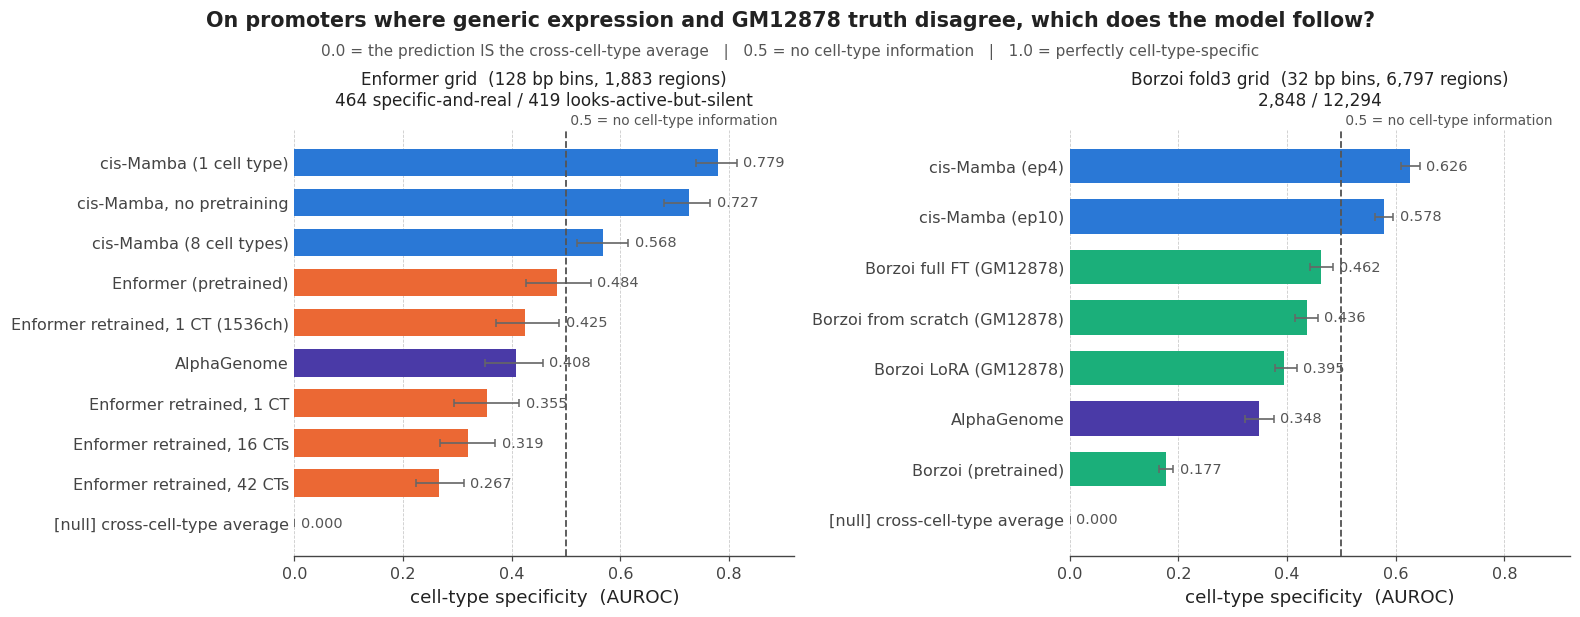

In [4]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================ PANEL A ======================================
def panel_A(SPEC_ENF_GRID, SPEC_BOR_GRID, FAMILY, FIGDIR, tidy, INK, INK2):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
    specs = [
        (SPEC_ENF_GRID, 'Enformer grid  (128 bp bins, 1,883 regions)\n'
                        '464 specific-and-real / 419 looks-active-but-silent'),
        (SPEC_BOR_GRID, 'Borzoi fold3 grid  (32 bp bins, 6,797 regions)\n'
                        '2,848 / 12,294'),
    ]
    for ax, (df, sub) in zip(axes, specs):
        y = np.arange(len(df))
        err = np.vstack([df.auroc - df.lo, df.hi - df.auroc])
        ax.barh(y, df.auroc, height=0.68,
                color=[FAMILY[f] for f in df.family], zorder=3,
                xerr=err, error_kw=dict(ecolor='#666666', lw=1.1, capsize=2.5))
        ax.set_yticks(y); ax.set_yticklabels(df.label); ax.invert_yaxis()
        for yi, (v, h) in enumerate(zip(df.auroc, df.hi)):
            ax.text(h + 0.012, yi, f'{v:.3f}', va='center', ha='left',
                    fontsize=9.5, color=INK2)
        # the three fixed anchors of this scale
        ax.axvline(0.5, ls='--', lw=1.2, color=INK2, zorder=4)
        ax.text(0.5, 1.005, ' 0.5 = no cell-type information', fontsize=9,
                color=INK2, ha='left', va='bottom',
                transform=ax.get_xaxis_transform())
        ax.set_xlim(0, 0.92)
        ax.set_title(sub, fontsize=11, pad=16)
        ax.set_xlabel('cell-type specificity  (AUROC)')
        tidy(ax, grid='x'); ax.spines['left'].set_visible(False)
    fig.text(0.5, 1.045,
             'On promoters where generic expression and GM12878 truth disagree, '
             'which does the model follow?',
             ha='center', fontsize=13.5, fontweight='bold', color=INK)
    fig.text(0.5, 0.995,
             '0.0 = the prediction IS the cross-cell-type average   |   '
             '0.5 = no cell-type information   |   1.0 = perfectly cell-type-specific',
             ha='center', fontsize=10, color=INK2)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/panelA_specificity.png', bbox_inches='tight')
    return fig

fig_A = panel_A(SPEC_ENF_GRID, SPEC_BOR_GRID, FAMILY, FIGDIR, tidy, INK, INK2)

---
## Panel G — same accuracy, opposite behaviour

The panel that justifies every other one. Both halves are the **Borzoi fold3 grid**, same
seven arms, and the left panel's order is carried over to the right so the eye can follow a
row across.

* **Left** — median per-region correlation against GM12878 CAGE, the number the field
  reports. Six arms inside a 0.053 span.
* **Right** — the specificity contrast, same arms, same order. A 0.449 span.

Borzoi full FT is the **most accurate arm on the grid** and still sits below 0.5, i.e. below
"no cell-type information at all". If the two panels ranked arms the same way, aggregate
accuracy would already settle the question and none of the rest of this poster would be
needed. They do not.

AlphaGenome is dropped from the accuracy half — it predicts in its own units, so its
correlation is an artifact rather than a result (see the results block). Its rank-based
AUROC is kept.

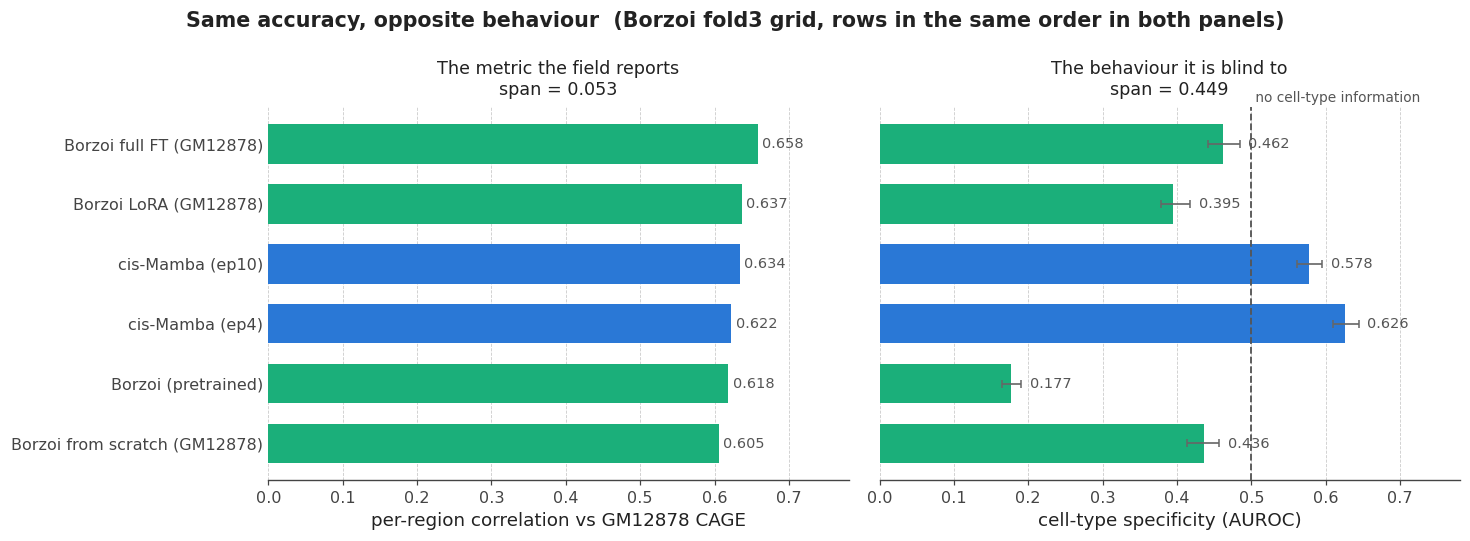

In [5]:
# ============================ PANEL G ======================================
def panel_G(df, FIGDIR, FAMILY, tidy, INK, INK2):
    d = df[(df.family != 'reference') & df.r_true.notna()
           & (df.family != 'alphagenome')].sort_values('r_true', ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
    y = np.arange(len(d))
    cols = [FAMILY[f] for f in d.family]

    ax = axes[0]
    ax.barh(y, d.r_true, height=0.66, color=cols, zorder=3)
    for yi, v in enumerate(d.r_true):
        ax.text(v + 0.006, yi, f'{v:.3f}', va='center', ha='left', fontsize=9.5, color=INK2)
    ax.set_yticks(y); ax.set_yticklabels(d.label); ax.invert_yaxis()
    ax.set_xlim(0, 0.78)
    ax.set_xlabel('per-region correlation vs GM12878 CAGE')
    ax.set_title('The metric the field reports\nspan = %.3f' % (d.r_true.max() - d.r_true.min()),
                 fontsize=11.5, pad=8)
    tidy(ax, grid='x'); ax.spines['left'].set_visible(False)

    ax = axes[1]
    ax.barh(y, d.auroc, height=0.66, color=cols, zorder=3,
            xerr=np.vstack([d.auroc - d.lo, d.hi - d.auroc]),
            error_kw=dict(ecolor='#666666', lw=1.1, capsize=2.5))
    for yi, (v, h) in enumerate(zip(d.auroc, d.hi)):
        ax.text(h + 0.012, yi, f'{v:.3f}', va='center', ha='left', fontsize=9.5, color=INK2)
    ax.axvline(0.5, ls='--', lw=1.2, color=INK2, zorder=4)
    ax.text(0.5, 1.005, ' no cell-type information', fontsize=9, color=INK2,
            ha='left', va='bottom', transform=ax.get_xaxis_transform())
    ax.set_xlim(0, 0.78)
    ax.set_xlabel('cell-type specificity (AUROC)')
    ax.set_title('The behaviour it is blind to\nspan = %.3f' % (d.auroc.max() - d.auroc.min()),
                 fontsize=11.5, pad=8)
    tidy(ax, grid='x'); ax.spines['left'].set_visible(False)

    fig.text(0.5, 1.03, 'Same accuracy, opposite behaviour  (Borzoi fold3 grid, '
             'rows in the same order in both panels)',
             ha='center', fontsize=13.5, fontweight='bold', color=INK)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/panelG_same_accuracy.png', bbox_inches='tight')
    return fig


fig_G = panel_G(SPEC_BOR_GRID, FIGDIR, FAMILY, tidy, INK, INK2)

---
## Panel H — the inversion

The same fact restated at a threshold, which is what makes it sayable out loud. Each arm is
scored at **its own p95** over allowed bins, so the background call rate is 5% for every arm
by construction and the two rates are comparable across models.

* x = fraction of **silent** promoters called (broadly active elsewhere, silent and closed here)
* y = fraction of **active** promoters called (active, open, low cross-cell-type average)

**Below the diagonal = the arm is more likely to fire at a promoter that is off than at one
that is on.** That is a statement about rates, not counts — the two classes are different
sizes — and it is the same information as AUROC < 0.5, restated where a reader can act on it.

The line for the poster: *at a matched 5% background call rate, pretrained Borzoi fires at
85% of promoters that are silent in GM12878 and only 41% of those that are active.*

Keep the scope honest: these promoters were **chosen** to be cases where generic expression
and GM12878 disagree, so a pure average-predictor lands at the bottom-right by construction.
The panel measures how heavily each arm leans on that shortcut. It is not a claim about
peak-calling genome-wide.

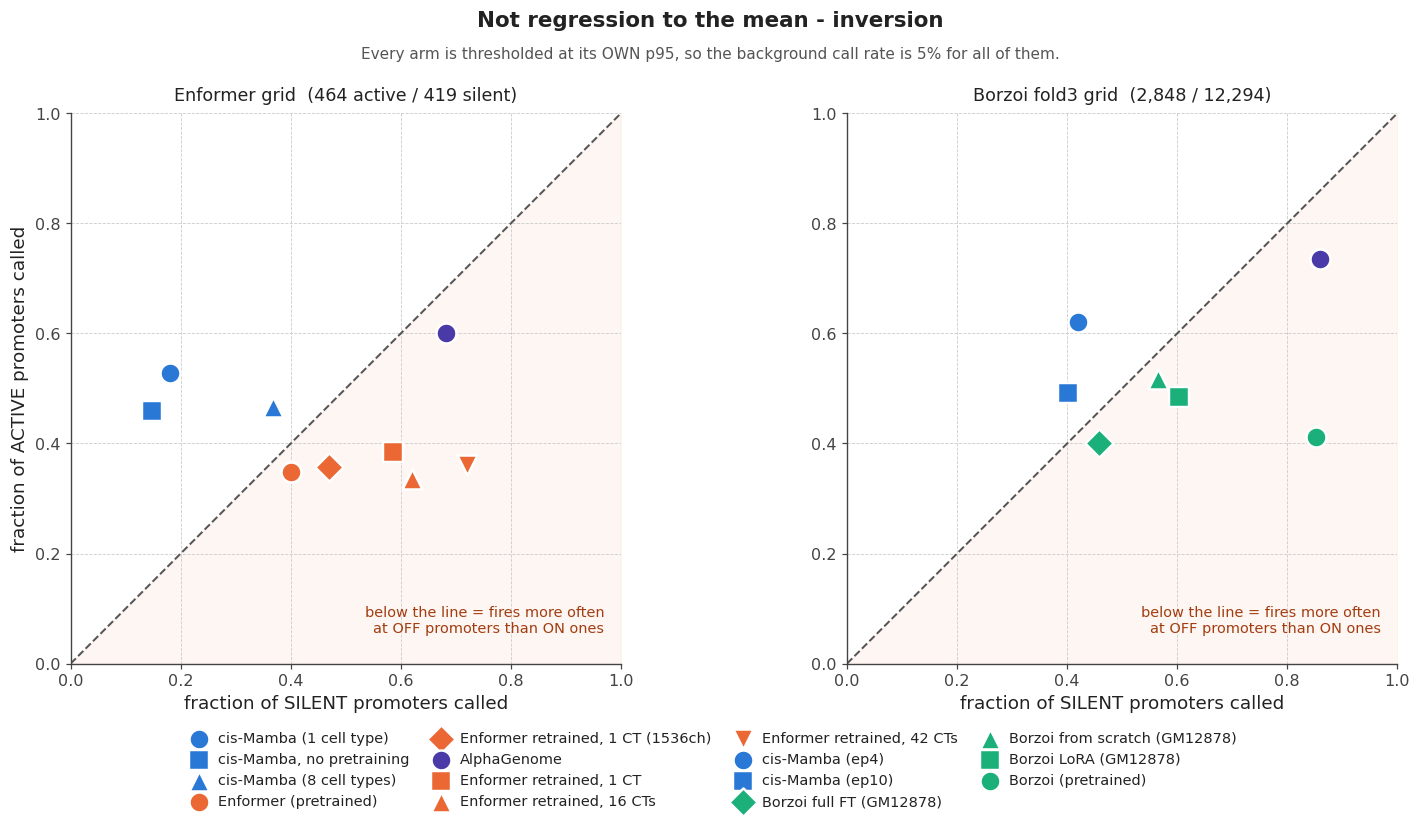

In [6]:
# ============================ PANEL H ======================================
def panel_H(enf, bor, FIGDIR, FAMILY, tidy, INK, INK2):
    # Nine points, and within a family the colour is identical -- so identity is carried by
    # colour (family) PLUS marker (variant), with one figure-level legend serving both facets.
    MARK = {'cis-Mamba (1 cell type)': 'o', 'cis-Mamba, no pretraining': 's',
            'cis-Mamba (8 cell types)': '^', 'cis-Mamba (ep4)': 'o', 'cis-Mamba (ep10)': 's',
            'Enformer (pretrained)': 'o', 'Enformer retrained, 1 CT': 's',
            'Enformer retrained, 1 CT (1536ch)': 'D', 'Enformer retrained, 16 CTs': '^',
            'Enformer retrained, 42 CTs': 'v', 'AlphaGenome': 'o',
            'Borzoi (pretrained)': 'o', 'Borzoi LoRA (GM12878)': 's',
            'Borzoi full FT (GM12878)': 'D', 'Borzoi from scratch (GM12878)': '^'}

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.4))
    handles = []
    for ax, (df, sub) in zip(axes, [
            (enf, 'Enformer grid  (464 active / 419 silent)'),
            (bor, 'Borzoi fold3 grid  (2,848 / 12,294)')]):
        d = df[df.family != 'reference']
        ax.fill_between([0, 1], [0, 1], 0, color='#eb6834', alpha=0.055, zorder=0)
        ax.plot([0, 1], [0, 1], ls='--', lw=1.3, color=INK2, zorder=1)
        for _, r in d.iterrows():
            h = ax.scatter(r.fp, r.recall, s=170, marker=MARK.get(r.label, 'o'),
                           color=FAMILY[r.family], zorder=3,
                           edgecolors='white', linewidths=1.6, label=r.label)
            handles.append((r.label, h))
        ax.text(0.97, 0.05, 'below the line = fires more often\nat OFF promoters than ON ones',
                fontsize=9.5, color='#a33d10', ha='right', va='bottom')
        ax.set_xlim(0, 1.0); ax.set_ylim(0, 1.0); ax.set_box_aspect(1)
        ax.set_xlabel('fraction of SILENT promoters called')
        ax.set_title(sub, fontsize=11.5, pad=8)
        tidy(ax, grid='both'); ax.tick_params(axis='both', length=3)
    axes[0].set_ylabel('fraction of ACTIVE promoters called')

    seen, hl = set(), []
    for lab, h in handles:
        if lab not in seen:
            seen.add(lab); hl.append((lab, h))
    fig.legend([h for _, h in hl], [l for l, _ in hl], loc='lower center', ncol=4,
               frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, -0.13),
               handletextpad=0.3, columnspacing=1.2)
    fig.text(0.5, 1.0, 'Not regression to the mean - inversion',
             ha='center', fontsize=14, fontweight='bold', color=INK)
    fig.text(0.5, 0.955, 'Every arm is thresholded at its OWN p95, so the background call '
             'rate is 5% for all of them.',
             ha='center', fontsize=10, color=INK2)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(f'{FIGDIR}/panelH_inversion.png', bbox_inches='tight')
    return fig


fig_H = panel_H(SPEC_ENF_GRID, SPEC_BOR_GRID, FIGDIR, FAMILY, tidy, INK, INK2)

---
## Panels D/E first — the recomputation

Panel B needs the distal eQTL numbers, so the compute block runs before it.

In [7]:
# ============================================================================
# PANELS D & E - recomputed from the raw ref/alt prediction arrays.
# Nothing here is read off a previous notebook: the arms are gated, sliced to a
# common physical window, and scored with average_precision_score (NOT the
# auc(recall, precision) trapezoid, which interpolates across tied scores and
# hands an out-of-window model ~(chance+1)/2 for free -- see EP_linking9 §5).
# ============================================================================
import numpy as np, pandas as pd, pickle, zarr
from sklearn.metrics import average_precision_score

QTL = '/data1/lesliec/sarthak/data/joint_playground/eQTL/EPCOTv2_LCLs/'
DSQ = '/data1/lesliec/sarthak/data/joint_playground/dsQTL'


def abs_logfc(win):
    """|log2 mean(ref) / mean(alt)| over the scoring window; 0 where unscored."""
    r, a = win[:, :, 0], win[:, :, 1]
    unscored = (r.sum(1) == 0) & (a.sum(1) == 0)
    out = np.zeros(len(r))
    v = ~unscored
    out[v] = np.log2(r[v].mean(1) / a[v].mean(1))
    return np.abs(out), ~unscored


# ------------------------------- eQTL ---------------------------------------
def load_eqtl():
    N, CENTER_BP = 1331, 2048
    q = pd.read_csv(QTL + 'LCLs.txt', sep=' ', header=None)
    q.columns = ['label', 'qtl_idx', 'gene_idx', 'chrom', 'gene_start',
                 'gene_end', 'strand', 'qtl_loc', 'ref', 'alt', 'sign_target']
    labels = q['label'].to_numpy()
    genes = sorted(pickle.load(open(QTL + 'genes.pickle', 'rb')).keys())
    t = np.loadtxt(QTL + 'ensemblTSS.txt', dtype='str')
    tss = {t[i, 0]: int(t[i, 1]) for i in range(t.shape[0])}
    dist = np.array([abs(tss[genes[q.iloc[i]['gene_idx']]] - (q.iloc[i]['qtl_loc'] - 1))
                     for i in range(N)])

    ARMS = [
        ('cis-Mamba (1 cell type)',   'ours',        'nomlm_maskonly.npy',      128),
        ('cis-Mamba, no pretraining', 'ours',        'nopretrain.npy',          128),
        ('cis-Mamba (8 cell types)',  'ours',        'immune.npy',              128),
        ('Enformer (pretrained)',     'enformer',    'enformer_eqtl.npy',       128),
        ('Borzoi (pretrained)',       'borzoi',      'borzoi_eqtl.npy',          32),
        ('Borzoi LoRA (GM12878)',     'borzoi',      'borzoi_eqtl_lorav2.npy',   32),
        ('Borzoi full FT (GM12878)',  'borzoi',      'borzoi_eqtl_trunk.npy',    32),
        ('Borzoi from scratch (GM12878)', 'borzoi',  'borzoi_eqtl_scratch.npy',  32),
        ('AlphaGenome',               'alphagenome', 'alphagenome_eqtl.zarr',     1),
    ]
    S, SC = {}, {}
    for lab, fam, f, bp in ARMS:
        if f.endswith('.zarr'):
            z = zarr.open(QTL + f, mode='r')
            full = np.asarray(z[:], dtype=np.float64)
        else:
            full = np.asarray(np.load(QTL + f, mmap_mode='r'), dtype=np.float64)
        assert full.shape[0] == N and full.shape[2] == 2, (lab, full.shape)
        nb = CENTER_BP // bp
        assert nb * bp == CENTER_BP, f'{lab}: {bp} bp bins do not tile {CENTER_BP} bp'
        cs = full.shape[1] // 2 - nb // 2
        S[lab], SC[lab] = abs_logfc(full[:, cs:cs + nb, :])
    common = np.logical_and.reduce([SC[l] for l, *_ in ARMS])
    # gate: an arm may only be compared where every arm could see the variant
    assert common.sum() > 0
    return dict(arms=ARMS, labels=labels, dist=dist, S=S, SC=SC, common=common)


def eqtl_table(E, row_mask):
    TH = [1_000, 10_000, 524_288 // 2]
    BINS = [('<1 kb\n(proximal)',   E['dist'] < TH[0]),
            ('1-10 kb\n(flanking)', (E['dist'] >= TH[0]) & (E['dist'] < TH[1])),
            ('10-262 kb\n(distal)', (E['dist'] >= TH[1]) & (E['dist'] < TH[2]))]
    rows, chance, ns = [], [], []
    for lab, fam, *_ in E['arms']:
        r = {'label': lab, 'family': fam}
        for nm, m in BINS:
            mm = m & row_mask
            r[nm] = average_precision_score(E['labels'][mm], E['S'][lab][mm])
        rows.append(r)
    for nm, m in BINS:
        mm = m & row_mask
        chance.append(E['labels'][mm].mean()); ns.append(int(mm.sum()))
    return pd.DataFrame(rows), [b[0] for b in BINS], chance, ns


# ------------------------------- dsQTL --------------------------------------
def load_dsqtl():
    q = pd.read_csv(f'{DSQ}/filtered_dsqtls.txt', sep='\t')
    labels = (q['label'].to_numpy() == 1).astype(int)
    ARMS = [
        ('cis-Mamba (1 cell type)',       'ours',        'nomlm_maskonly.npy'),
        ('Enformer (pretrained)',         'enformer',    'enformer_dsqtl.npy'),
        ('Enformer retrained (GM12878)',  'enformer',    'enformer_dsqtl_retrained-dsqtl.npy'),
        ('Borzoi (pretrained)',           'borzoi',      'borzoi_dsqtl_pretrained_1288.npy'),
        ('Borzoi LoRA (GM12878)',         'borzoi',      'borzoi_dsqtl_lorav2.npy'),
        ('Borzoi full FT (GM12878)',      'borzoi',      'borzoi_dsqtl_trunk.npy'),
        ('Borzoi from scratch (GM12878)', 'borzoi',      'borzoi_dsqtl_scratch.npy'),
        ('AlphaGenome',                   'alphagenome', 'alphagenome_dsqtl.zarr'),
    ]
    S, SC = {}, {}
    for lab, fam, f in ARMS:
        if f.endswith('zarr'):
            d = np.asarray(zarr.open(f'{DSQ}/{f}')[:, :, :], dtype=np.float64)
        elif 'borzoi' in f:
            a = np.load(f'{DSQ}/{f}', mmap_mode='r')
            m, h = 6144 // 2, 2048 // 32 // 2       # same 2048 bp window as Enformer
            d = np.asarray(a[:, m - h:m + h, :], dtype=np.float64)
        else:
            d = np.asarray(np.load(f'{DSQ}/{f}'), dtype=np.float64)
            if 'enformer' in f:
                d = d[:, 440:456, :]                # 16 x 128 bp = 2048 bp
        S[lab], SC[lab] = abs_logfc(d)
    common = np.logical_and.reduce([SC[l] for l, *_ in ARMS])
    rows = [{'label': l, 'family': fam,
             'AP': average_precision_score(labels[common], S[l][common])}
            for l, fam, _ in ARMS]
    return (pd.DataFrame(rows).sort_values('AP', ascending=False).reset_index(drop=True),
            float(labels[common].mean()), int(common.sum()))

In [8]:
E = load_eqtl()
print(f'common support: {E["common"].sum()} / 1331 variants scorable by every arm')

df_eqtl_all, BINNAMES, CH_ALL, NS_ALL = eqtl_table(E, np.ones(1331, bool))
df_eqtl,     BINNAMES, CH_COM, NS_COM = eqtl_table(E, E['common'])

print('\n--- benchmark as written (all variants) ---')
_pretty = lambda df: df.set_index('label').drop(columns='family').rename(
    columns=lambda c: c.replace('\n', ' ')).round(4)
display(_pretty(df_eqtl_all))
print('--- common support (the honest comparison) ---')
display(_pretty(df_eqtl))
print('chance:', [round(c, 4) for c in CH_COM], '  n:', NS_COM)

common support: 1023 / 1331 variants scorable by every arm

--- benchmark as written (all variants) ---


,<1 kb (proximal),1-10 kb (flanking),10-262 kb (distal)
label,,,
cis-Mamba (1 cell type),0.6068,0.5350,0.3497
"cis-Mamba, no pretraining",0.5435,0.3781,0.3143
cis-Mamba (8 cell types),0.6735,0.5597,0.3828
Enformer (pretrained),0.6582,0.6536,0.3620
Borzoi (pretrained),0.6778,0.6464,0.3618
Borzoi LoRA (GM12878),0.6910,0.6655,0.3669
Borzoi full FT (GM12878),0.7125,0.6791,0.3611
Borzoi from scratch (GM12878),0.6807,0.6232,0.3793
AlphaGenome,0.7086,0.7603,0.5236


--- common support (the honest comparison) ---


,<1 kb (proximal),1-10 kb (flanking),10-262 kb (distal)
label,,,
cis-Mamba (1 cell type),0.6068,0.5350,0.4023
"cis-Mamba, no pretraining",0.5435,0.3781,0.3367
cis-Mamba (8 cell types),0.6735,0.5597,0.4459
Enformer (pretrained),0.6582,0.6536,0.4082
Borzoi (pretrained),0.6778,0.6464,0.4230
Borzoi LoRA (GM12878),0.6910,0.6655,0.4274
Borzoi full FT (GM12878),0.7125,0.6791,0.4190
Borzoi from scratch (GM12878),0.6807,0.6232,0.4250
AlphaGenome,0.7086,0.7603,0.5326


chance: [0.4227, 0.2397, 0.1024]   n: [291, 146, 586]


---
## Panel B — the tradeoff, controlled for architecture

This is the panel no one else can make: the same architecture trained on 1 vs 8 cell types,
and the same for retrained Enformer at 1 / 16 / 42. Breadth is a **dial**, and it moves the two
axes in opposite directions.

Left: specificity falls monotonically with breadth, in *both* architectures.
Right: distal eQTL sensitivity rises with breadth, and cis-Mamba at 8 cell types (16 tracks)
passes every Borzoi and Enformer arm.

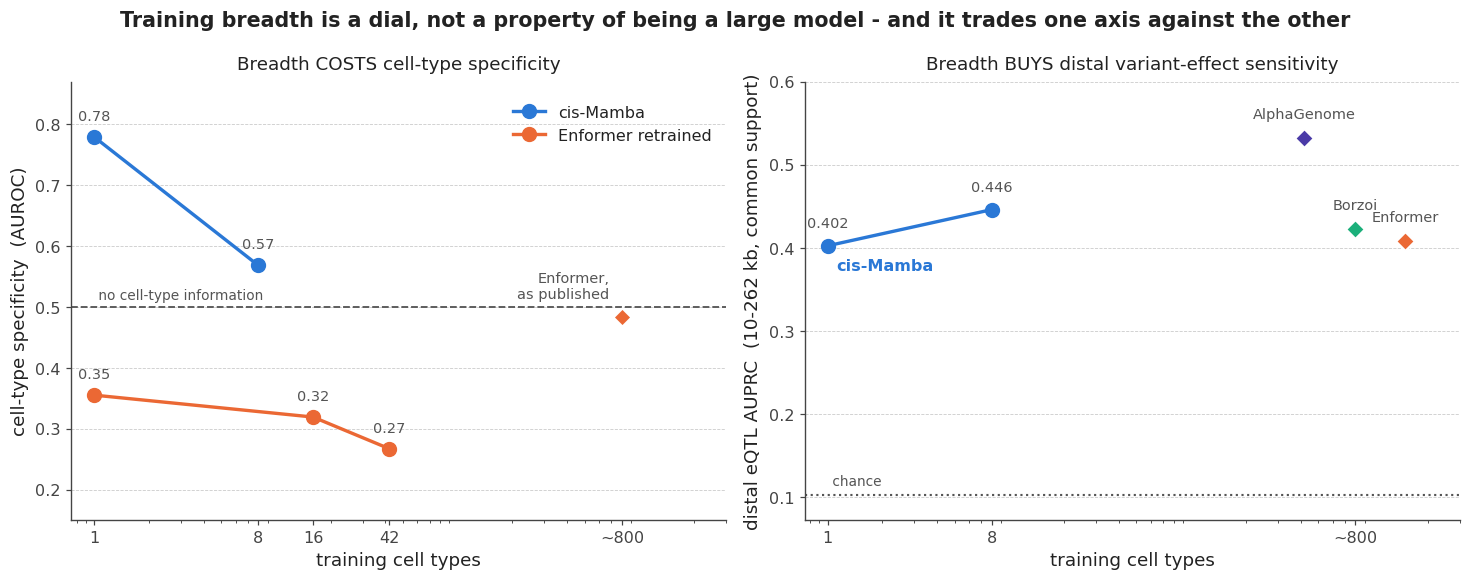

In [9]:
# ============================ PANEL B ======================================
def panel_B(FAMILY, FIGDIR, tidy, INK, INK2, eqtl_by_nct):
    """The tradeoff: breadth costs specificity and buys variant-effect sensitivity."""
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

    # -- B1: specificity falls as training breadth grows -----------------
    ax = axes[0]
    # read from the live table so this panel cannot drift from Panel A
    _s = SPEC_ENF_GRID.set_index('label')['auroc']
    series = [
        ('cis-Mamba',          'ours',     [1, 8],
         [float(_s['cis-Mamba (1 cell type)']), float(_s['cis-Mamba (8 cell types)'])]),
        ('Enformer retrained', 'enformer', [1, 16, 42],
         [float(_s['Enformer retrained, 1 CT']), float(_s['Enformer retrained, 16 CTs']),
          float(_s['Enformer retrained, 42 CTs'])]),
    ]
    for lab, fam, x, v in series:
        ax.plot(x, v, marker='o', ms=9, lw=2.2, color=FAMILY[fam],
                label=lab, zorder=3)
        for xi, vi in zip(x, v):
            ax.annotate(f'{vi:.2f}', (xi, vi), textcoords='offset points',
                        xytext=(0, 11), ha='center', fontsize=9.5, color=INK2)
    ax.scatter([800], [float(_s['Enformer (pretrained)'])], marker='D', s=70, color=FAMILY['enformer'],
               zorder=4, edgecolors='white', linewidths=1.4)
    ax.annotate('Enformer,\nas published', (800, float(_s['Enformer (pretrained)'])),
                textcoords='offset points', xytext=(-8, 12), ha='right',
                fontsize=9.5, color=INK2)
    ax.axhline(0.5, ls='--', lw=1.2, color=INK2, zorder=2)
    ax.text(1, 0.507, ' no cell-type information', fontsize=9, color=INK2,
            ha='left', va='bottom')
    ax.set_xscale('log'); ax.set_xticks([1, 8, 16, 42, 800])
    ax.set_xticklabels(['1', '8', '16', '42', '~800'])
    ax.set_xlabel('training cell types')
    ax.set_ylabel('cell-type specificity  (AUROC)')
    ax.set_ylim(0.15, 0.87)
    ax.set_title('Breadth COSTS cell-type specificity', fontsize=12, pad=8)
    ax.set_xlim(0.75, 3000)
    ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.0, 0.98))
    tidy(ax); ax.tick_params(axis='x', length=3)

    # -- B2: distal eQTL sensitivity rises with breadth ------------------
    ax = axes[1]
    x, v = eqtl_by_nct['ours']
    ax.plot(x, v, marker='o', ms=9, lw=2.2, color=FAMILY['ours'], zorder=3)
    for xi, vi in zip(x, v):
        ax.annotate(f'{vi:.3f}', (xi, vi), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=9.5, color=INK2)
    # the line is a single series -- direct-label it instead of a legend box
    ax.annotate('cis-Mamba', (x[0], v[0]), textcoords='offset points',
                xytext=(6, -16), ha='left', fontsize=10.5,
                color=FAMILY['ours'], fontweight='bold')
    # the three published models sit at ~800 cell types; jitter so the markers
    # and their direct labels do not collide
    jitter = {'AlphaGenome': 420.0, 'Borzoi': 800.0, 'Enformer': 1500.0}
    for lab, fam, _xv, vv in eqtl_by_nct['refs']:
        xv = jitter[lab]
        ax.scatter([xv], [vv], marker='D', s=75, color=FAMILY[fam], zorder=4,
                   edgecolors='white', linewidths=1.4)
        ax.annotate(lab, (xv, vv), textcoords='offset points',
                    xytext=(0, 13), ha='center', fontsize=9.5, color=INK2)
    ax.axhline(eqtl_by_nct['chance'], ls=':', lw=1.4, color=INK2, zorder=2)
    ax.text(1, eqtl_by_nct['chance'] + 0.008, ' chance', fontsize=9,
            color=INK2, ha='left', va='bottom')
    ax.set_xscale('log'); ax.set_xticks([1, 8, 800])
    ax.set_xticklabels(['1', '8', '~800'])
    ax.set_xlim(0.75, 3000)
    ax.set_ylim(eqtl_by_nct['chance'] - 0.03, 0.60)
    ax.set_xlabel('training cell types')
    ax.set_ylabel('distal eQTL AUPRC  (10-262 kb, common support)')
    ax.set_title('Breadth BUYS distal variant-effect sensitivity',
                 fontsize=12, pad=8)
    tidy(ax); ax.tick_params(axis='x', length=3)

    fig.text(0.5, 1.02,
             'Training breadth is a dial, not a property of being a large model - '
             'and it trades one axis against the other',
             ha='center', fontsize=13.5, fontweight='bold', color=INK)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/panelB_tradeoff.png', bbox_inches='tight')
    return fig


d = df_eqtl.set_index('label')
DIST = BINNAMES[2]
eqtl_by_nct = dict(
    ours=([1, 8], [float(d.loc['cis-Mamba (1 cell type)', DIST]),
                   float(d.loc['cis-Mamba (8 cell types)', DIST])]),
    refs=[('AlphaGenome', 'alphagenome', 800, float(d.loc['AlphaGenome', DIST])),
          ('Borzoi',      'borzoi',      800, float(d.loc['Borzoi (pretrained)', DIST])),
          ('Enformer',    'enformer',    800, float(d.loc['Enformer (pretrained)', DIST]))],
    chance=CH_COM[2])

fig_B = panel_B(FAMILY, FIGDIR, tidy, INK, INK2, eqtl_by_nct)

---
## Panel C — you cannot finetune your way out of it

All four Borzoi arms below are trained or adapted on the *same* GM12878 data. LoRA, a full
trunk finetune, and a from-scratch retrain all move specificity a long way up from stock
Borzoi — and all three plateau below a model that simply takes accessibility as an input.

Training configuration of the adapted arms (`comparing_model5` §10):

| arm | init | lr | trainable params | best epoch | stopped by |
|---|---|---|---|---|---|
| Borzoi LoRA v2 | pretrained | 6e-5 | 333,443 | 0 | early stop |
| Borzoi full FT (trunk) | pretrained | 1e-5 | 171.6M | 8 | early stop |
| Borzoi from scratch | random | 6e-5 | 171.6M | 15 | 168 h wall clock |

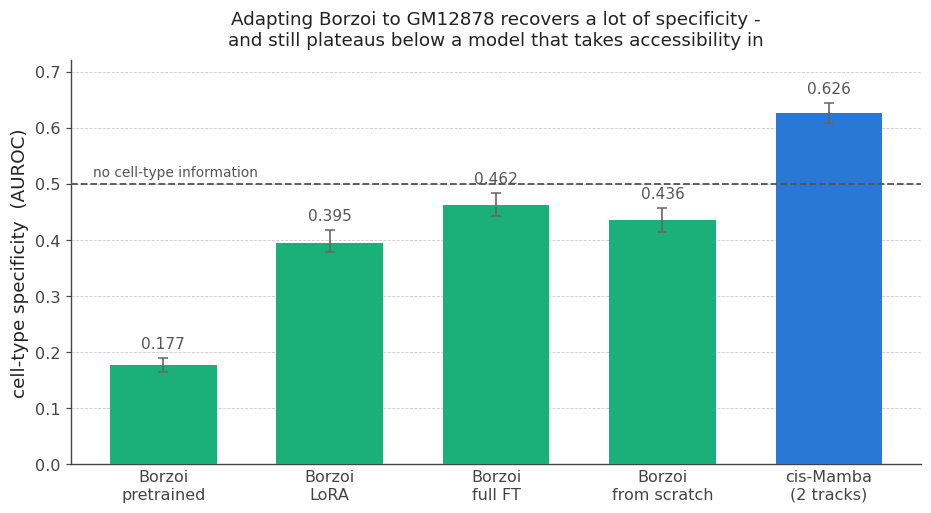

In [10]:
# ============================ PANEL C ======================================
def panel_C(FAMILY, FIGDIR, tidy, INK, INK2):
    """Adapting a multitask model to GM12878 helps a lot, and still plateaus."""
    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    labs = ['Borzoi\npretrained', 'Borzoi\nLoRA', 'Borzoi\nfull FT',
            'Borzoi\nfrom scratch', 'cis-Mamba\n(2 tracks)']
    vals = [0.177, 0.395, 0.462, 0.436, 0.626]
    lo   = [0.165, 0.378, 0.442, 0.414, 0.609]
    hi   = [0.190, 0.418, 0.484, 0.456, 0.644]
    cols = [FAMILY['borzoi']] * 4 + [FAMILY['ours']]
    x = np.arange(len(labs))
    err = np.vstack([np.array(vals) - lo, np.array(hi) - vals])
    ax.bar(x, vals, width=0.64, color=cols, zorder=3, xerr=None, yerr=err,
           error_kw=dict(ecolor='#666666', lw=1.1, capsize=3))
    for xi, (v, h) in enumerate(zip(vals, hi)):
        ax.text(xi, h + 0.012, f'{v:.3f}', ha='center', va='bottom',
                fontsize=10, color=INK2)
    ax.axhline(0.5, ls='--', lw=1.2, color=INK2, zorder=4)
    ax.text(-0.42, 0.508, 'no cell-type information', fontsize=9,
            color=INK2, ha='left', va='bottom')
    ax.set_xticks(x); ax.set_xticklabels(labs)
    ax.set_ylabel('cell-type specificity  (AUROC)')
    ax.set_ylim(0, 0.72)
    ax.set_title('Adapting Borzoi to GM12878 recovers a lot of specificity -\n'
                 'and still plateaus below a model that takes accessibility in',
                 fontsize=12, pad=10)
    tidy(ax)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/panelC_adaptation.png', bbox_inches='tight')
    return fig


fig_C = panel_C(FAMILY, FIGDIR, tidy, INK, INK2)

---
## Panel D — the sequence channel, proved without an ablation

In eQTL scoring the ref and alt sequences are fed with the **identical accessibility track**.
Any predicted effect is therefore attributable to the sequence channel by construction. This is
a stronger statement than a seq-only ablation, because it is the same model being benchmarked
rather than a retrained one.

Two things to read off it:

* cis-Mamba (8 cell types) is the best non-AlphaGenome arm on **distal** variants (0.446).
  Its relative position improves monotonically with distance — proximal 6th, flanking 7th,
  distal 2nd — which is what you expect if the benchmarks where multitask breadth wins are
  promoter-driven.
* **Borzoi retrained from scratch on GM12878 does not collapse here** (distal 0.425 vs 0.423
  pretrained). Retraining costs specificity nothing and costs eQTL nothing; it costs dsQTL a
  lot (Panel E).
* **The pretraining ablation is the worst arm in all three bins** (0.543 / 0.378 / 0.337). Dropping the masked-accessibility pretraining costs more here than anywhere else in the notebook — see the Panel A section for why that is the expected direction.

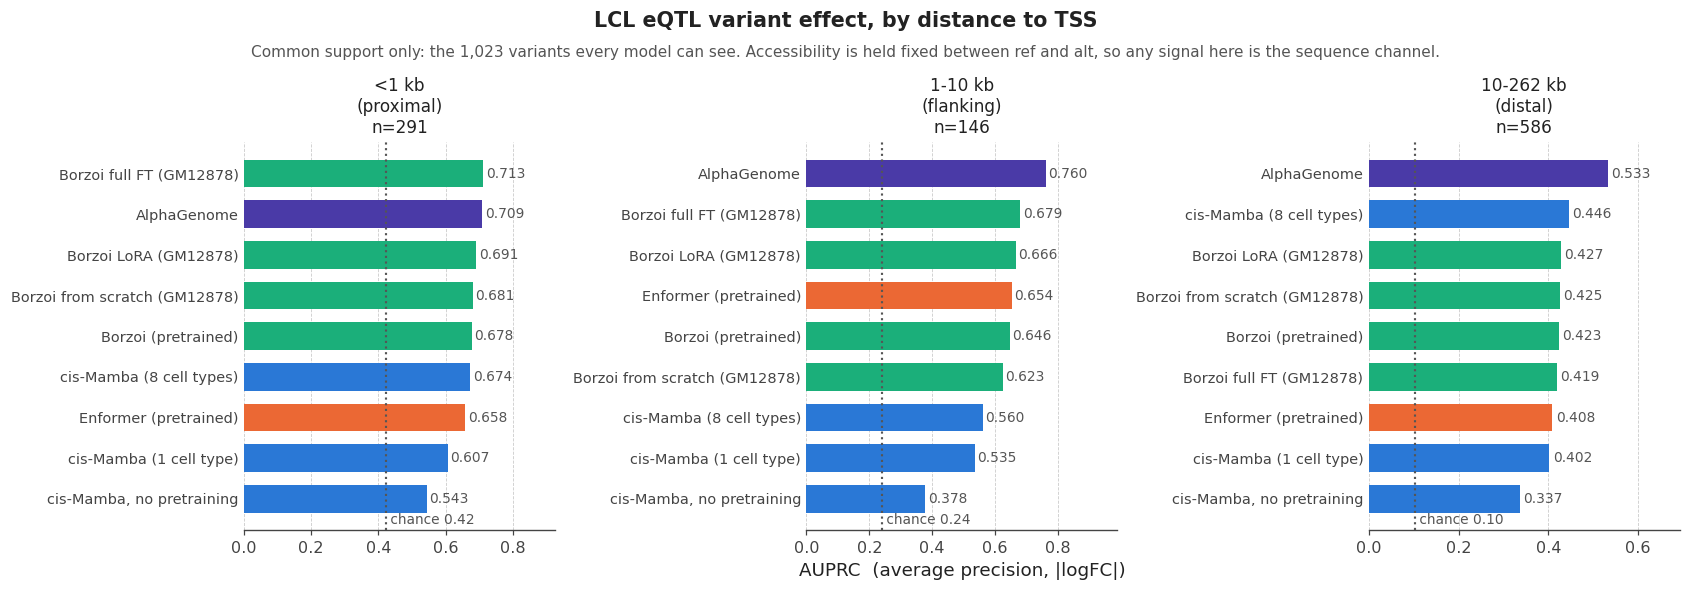

In [11]:
import numpy as np, matplotlib.pyplot as plt

# ============================ PANEL D ======================================
def panel_D(df, binnames, chance, ns, FAMILY, FIGDIR, tidy, INK, INK2):
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.9))
    for bi, (ax, nm) in enumerate(zip(axes, binnames)):
        sub = df.sort_values(nm, ascending=False)
        y = np.arange(len(sub))
        ax.barh(y, sub[nm], height=0.68,
                color=[FAMILY[f] for f in sub.family], zorder=3)
        ax.set_yticks(y); ax.set_yticklabels(sub.label, fontsize=9.5)
        ax.invert_yaxis()
        for yi, v in enumerate(sub[nm]):
            ax.text(v + 0.008, yi, f'{v:.3f}', va='center', ha='left',
                    fontsize=9, color=INK2)
        ax.axvline(chance[bi], ls=':', lw=1.4, color=INK2, zorder=4)
        ax.text(chance[bi], 0.01, f' chance {chance[bi]:.2f}', fontsize=9,
                color=INK2, ha='left', va='bottom',
                transform=ax.get_xaxis_transform())
        ax.set_xlim(0, min(1.0, sub[nm].max() * 1.30))
        ax.set_title(f'{nm}\nn={ns[bi]}', fontsize=11)
        tidy(ax, grid='x'); ax.spines['left'].set_visible(False)
    axes[1].set_xlabel('AUPRC  (average precision, |logFC|)')
    fig.text(0.5, 1.06, 'LCL eQTL variant effect, by distance to TSS',
             ha='center', fontsize=13.5, fontweight='bold', color=INK)
    fig.text(0.5, 1.005,
             'Common support only: the 1,023 variants every model can see. '
             'Accessibility is held fixed between ref and alt, so any signal here '
             'is the sequence channel.',
             ha='center', fontsize=10, color=INK2)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/panelD_eqtl.png', bbox_inches='tight')
    return fig

fig_D = panel_D(df_eqtl, BINNAMES, CH_COM, NS_COM, FAMILY, FIGDIR, tidy, INK, INK2)

---
## Panel E — chromatin QTLs

Same logic, on DNase QTLs in GM12878. Here the small-data retrains *do* collapse: Enformer
retrained on GM12878 drops to 0.490 and Borzoi from scratch to 0.379, both well below their
pretrained counterparts, while cis-Mamba — trained on 2 tracks — sits third.

,label,family,AP
0,AlphaGenome,alphagenome,0.6263
1,Enformer (pretrained),enformer,0.5786
2,cis-Mamba (1 cell type),ours,0.5508
3,Borzoi LoRA (GM12878),borzoi,0.5471
4,Borzoi (pretrained),borzoi,0.5384
5,Borzoi full FT (GM12878),borzoi,0.5356
6,Enformer retrained (GM12878),enformer,0.4904
7,Borzoi from scratch (GM12878),borzoi,0.3792


chance 0.0248, n 17,506


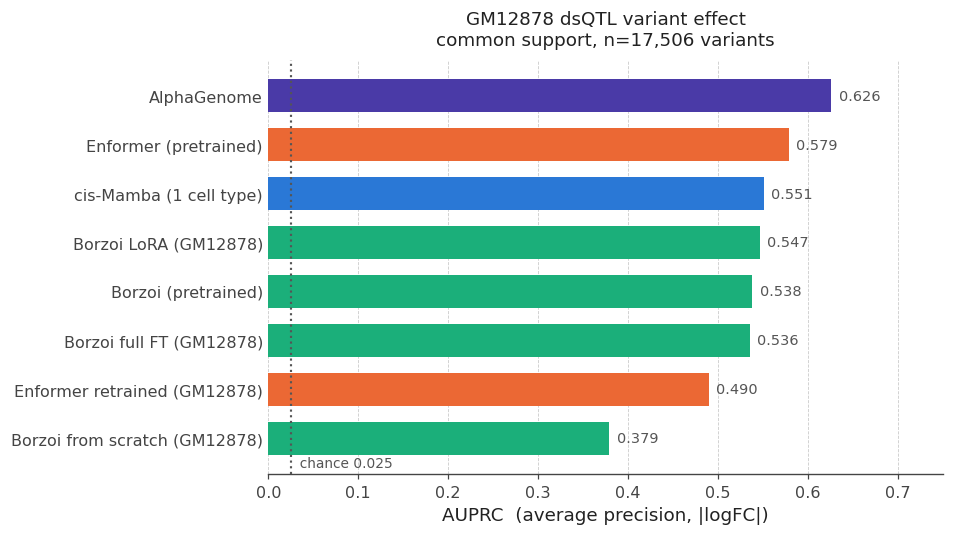

In [12]:
# ============================ PANEL E ======================================
def panel_E(df, chance, n, FAMILY, FIGDIR, tidy, INK, INK2):
    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    y = np.arange(len(df))
    ax.barh(y, df.AP, height=0.68, color=[FAMILY[f] for f in df.family], zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(df.label); ax.invert_yaxis()
    for yi, v in enumerate(df.AP):
        ax.text(v + 0.008, yi, f'{v:.3f}', va='center', ha='left',
                fontsize=9.5, color=INK2)
    ax.axvline(chance, ls=':', lw=1.4, color=INK2, zorder=4)
    ax.text(chance, 0.01, f'  chance {chance:.3f}', fontsize=9, color=INK2,
            ha='left', va='bottom', transform=ax.get_xaxis_transform())
    ax.set_xlim(0, 0.75)
    ax.set_xlabel('AUPRC  (average precision, |logFC|)')
    ax.set_title(f'GM12878 dsQTL variant effect\n'
                 f'common support, n={n:,} variants',
                 fontsize=12, pad=10)
    tidy(ax, grid='x'); ax.spines['left'].set_visible(False)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/panelE_dsqtl.png', bbox_inches='tight')
    return fig


ds_df, DS_CHANCE, DS_N = load_dsqtl()
display(ds_df.round(4))
print(f'chance {DS_CHANCE:.4f}, n {DS_N:,}')
fig_E = panel_E(ds_df, DS_CHANCE, DS_N, FAMILY, FIGDIR, tidy, INK, INK2)

---
## Panel F — the control, and the honest caveat

Panel A defines its classes partly **using** accessibility, which makes accessibility a perfect
predictor by construction and therefore useless as a comparator. This panel removes it from the
labels and scores it as a method alongside the models. Nothing else changes.

Measured DNase/ATAC is a *measurement of GM12878*, not a prediction, so it is expected to lead.
The quantity that carries the argument is the **margin** to it:

| observed | reading |
|---|---|
| accessibility-input model ≈ accessibility alone | the model is a passthrough; the sequence contribution to *specificity* is ~0 |
| accessibility-input model **>** accessibility alone | sequence *and* chromatin beat either — the result worth claiming |
| accessibility-input model < accessibility alone | the model is destroying information its input already contained |

**What the data actually says: cis-Mamba lands in the first row, not the second.**
On the Enformer grid it is 0.538 vs 0.556 for measured ATAC (−0.018, inside the CIs); on the
Borzoi grid 0.354 vs 0.389 for measured DNase (−0.034). Every model that does *not* take
accessibility sits 0.20–0.39 below the measurement.

So the claim the poster can make is **"chromatin state supplies the cell-type information that
sequence alone cannot encode, and this architecture uses it where the multitask models cannot"** —
not "sequence + chromatin beats chromatin alone", which is not yet supported. Panels D and E are
what keep the sequence channel from being idle: there accessibility is held fixed and the model
still ranks causal variants.

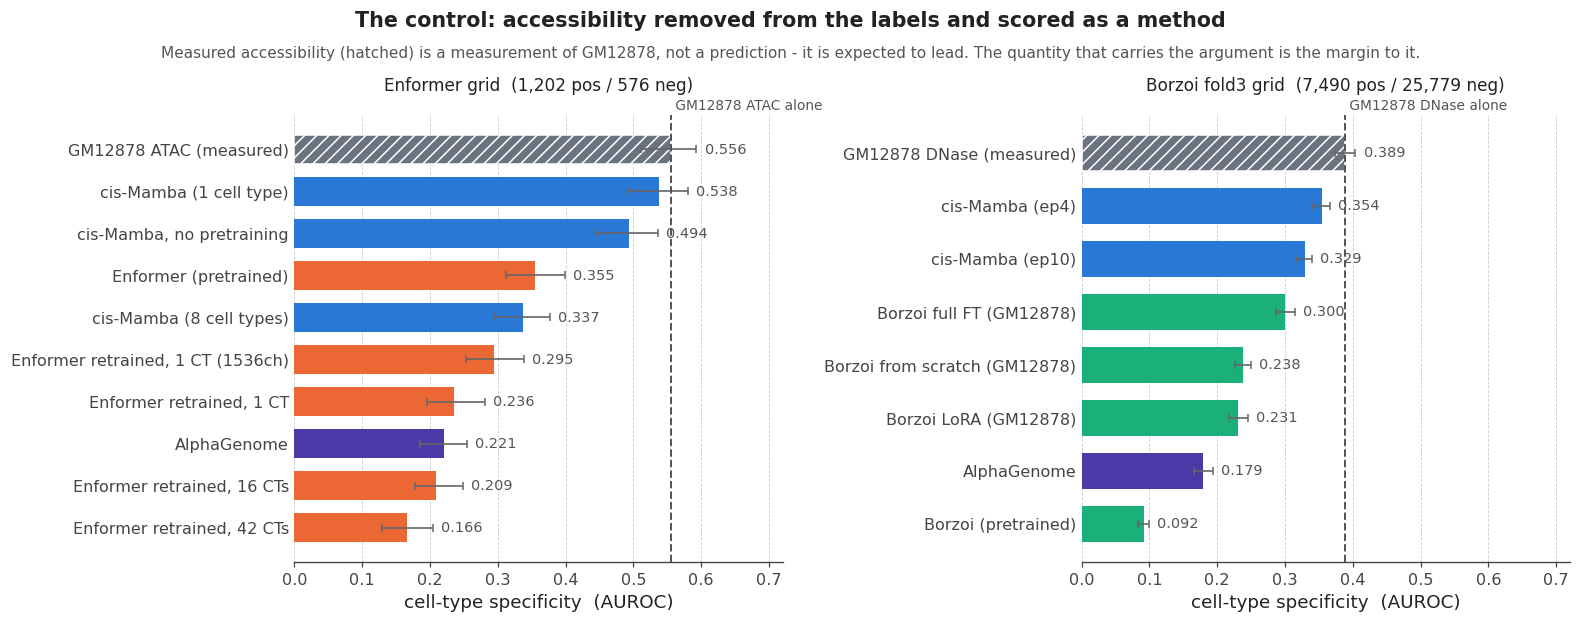

In [13]:
# ============================ PANEL F ======================================
def panel_F(ACC_ENF, ACC_BOR, FAMILY, FIGDIR, tidy, INK, INK2):
    """The control that decides whether the model beats its own input."""
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
    for ax, (df, sub, accname) in zip(axes, [
            (ACC_ENF, 'Enformer grid  (1,202 pos / 576 neg)', 'GM12878 ATAC'),
            (ACC_BOR, 'Borzoi fold3 grid  (7,490 pos / 25,779 neg)', 'GM12878 DNase')]):
        y = np.arange(len(df))
        err = np.vstack([df.auroc - df.lo, df.hi - df.auroc])
        cols = [FAMILY[f] for f in df.family]
        ax.barh(y, df.auroc, height=0.68, color=cols, zorder=3, xerr=err,
                error_kw=dict(ecolor='#666666', lw=1.1, capsize=2.5))
        # the measured assay is a reference, not a competitor -- hatch it
        ref_i = int(np.where(df.family == 'reference')[0][0])
        ax.patches[ref_i].set_hatch('///')
        ax.patches[ref_i].set_edgecolor('white')
        ax.set_yticks(y); ax.set_yticklabels(df.label); ax.invert_yaxis()
        for yi, (v, h) in enumerate(zip(df.auroc, df.hi)):
            ax.text(h + 0.012, yi, f'{v:.3f}', va='center', ha='left',
                    fontsize=9.5, color=INK2)
        acc = float(df.loc[df.family == 'reference', 'auroc'].iloc[0])
        ax.axvline(acc, ls='--', lw=1.3, color=INK2, zorder=4)
        ax.text(acc, 1.005, f' {accname} alone', fontsize=9, color=INK2,
                ha='left', va='bottom', transform=ax.get_xaxis_transform())
        ax.set_xlim(0, 0.72)
        ax.set_title(sub, fontsize=11, pad=16)
        ax.set_xlabel('cell-type specificity  (AUROC)')
        tidy(ax, grid='x'); ax.spines['left'].set_visible(False)
    fig.text(0.5, 1.055,
             'The control: accessibility removed from the labels and scored as a method',
             ha='center', fontsize=13.5, fontweight='bold', color=INK)
    fig.text(0.5, 1.0,
             'Measured accessibility (hatched) is a measurement of GM12878, not a '
             'prediction - it is expected to lead. The quantity that carries the '
             'argument is the margin to it.',
             ha='center', fontsize=10, color=INK2)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/panelF_accessibility_control.png', bbox_inches='tight')
    return fig


fig_F = panel_F(ACC_ENF_GRID, ACC_BOR_GRID, FAMILY, FIGDIR, tidy, INK, INK2)

---
## Supplementary — the design-free companion to Panel A

Partial correlations, needing no labels, thresholds or accessibility.
`index = r(pred, TRUE | AVG) − r(pred, AVG | TRUE)`; below 0 means the model explains the
cross-cell-type average better than it explains GM12878. A claim that survives both a
sharp-but-constructed metric and a blunt-but-unarguable one is much harder to dismiss.

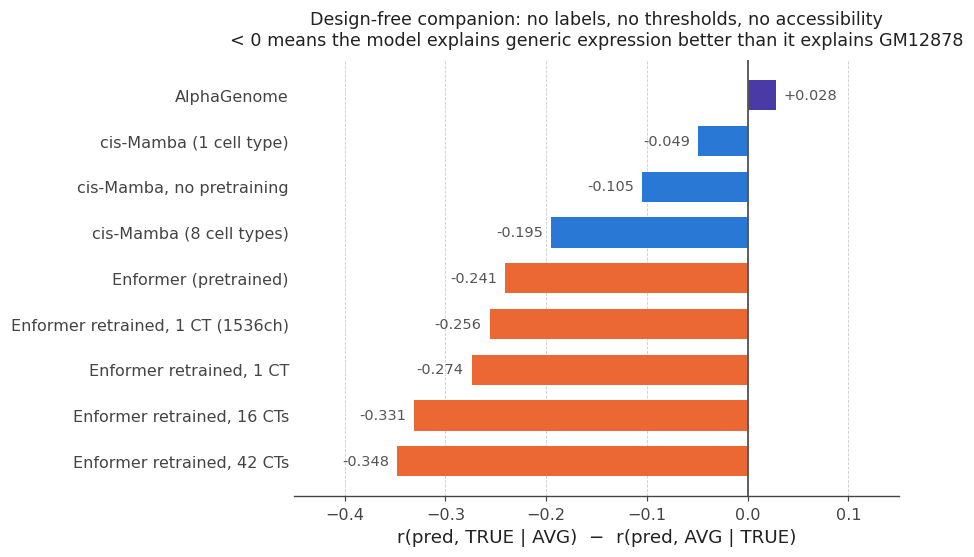

In [14]:
fig, ax = plt.subplots(figsize=(8.4, 5.2))
p = PARTIAL_ENF.sort_values('index', ascending=False).reset_index(drop=True)
y = np.arange(len(p))
ax.barh(y, p['index'], height=0.66, color=[FAMILY[f] for f in p.family], zorder=3)
ax.set_yticks(y); ax.set_yticklabels(p.label); ax.invert_yaxis()
for yi, v in enumerate(p['index']):
    ax.text(v - 0.008 if v < 0 else v + 0.008, yi, f'{v:+.3f}', va='center',
            ha='right' if v < 0 else 'left', fontsize=9.5, color=INK2)
ax.axvline(0, lw=1.2, color=INK2, zorder=4)
ax.set_xlim(-0.45, 0.15)
ax.set_xlabel('r(pred, TRUE | AVG)  −  r(pred, AVG | TRUE)')
ax.set_title('Design-free companion: no labels, no thresholds, no accessibility\n'
             '< 0 means the model explains generic expression better than it explains GM12878',
             fontsize=11.5, pad=10)
tidy(ax, grid='x'); ax.spines['left'].set_visible(False)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/supp_partial_correlations.png', bbox_inches='tight')


---
## What the data changed about the abstract

Four claims in the current abstract do not survive contact with these tables. Fixing them makes
the poster stronger, not weaker — the headline result is bigger than advertised.

**1. "Retrained multitask models perform substantially worse on all tasks" — not true on eQTL.**
Borzoi from scratch on GM12878 scores 0.425 distal, statistically indistinguishable from
pretrained Borzoi (0.423) and above the full finetune (0.419). It *does* collapse on dsQTL
(0.379 vs 0.538) and it *is* far more cell-type-specific than stock Borzoi (0.436 vs 0.177).
The correct claim: **retraining on small data buys specificity and costs chromatin-QTL
sensitivity — and still does not reach an accessibility-conditioned model.**

**2. The eQTL numbers are the contaminated convention.** The abstract's 0.38 / 0.36 / 0.46 come
from scoring all 1,331 variants, where Enformer's 244 unseeable distal rows are scored 0.0 and
ranked last — free accuracy, since they are overwhelmingly negatives. On common support the
ordering changes and improves for us: **cis-Mamba (8 CTs) 0.446 > Borzoi LoRA 0.427 > Borzoi
scratch 0.425 > Borzoi 0.423 > Borzoi full FT 0.419 > Enformer 0.408**, with AlphaGenome at
0.533. cis-Mamba is the best non-AlphaGenome arm on distal eQTLs, not a near-tie.

**3. E–G linking: "cis-Mamba performs better than Enformer" is the reverse of what `EP_linking9`
finds.** On the 1,763 pairs every model can perturb: AlphaGenome 0.797 ≫ Enformer 0.656 >
ours-striped 0.572 > Borzoi 0.542 > ours-borzoi 0.495 > ours-enformer 0.422. Worse, on the full
benchmark most of our arms do not beat a **1/distance baseline** (0.436 overall; ours-striped
0.439), and the perturbation ablation shows the sequence channel contributing almost nothing to
the E–G score (`acc` ≈ `shuffle+acc` > `shuffle` for all three joint arms, with
`r(acc, shuffle+acc)` = 0.98). Effect-size correlation on regulated pairs is also weakly
*negative* for every one of our arms (−0.01 to −0.11) where Borzoi and Enformer are positive.

  **Recommendation: cut E–G linking from the poster.** It does not support the story, the model
  barely clears a distance baseline, and it invites the "your model is not reading sequence"
  attack at exactly the point where the evidence is weakest. Keep it for the paper, after the
  direction and effect-size issues are chased.

**4. Model identity.** "cis-Mamba" is currently four different models across the panels — a
128 bp-bin Enformer-decoder model (1 CT / 8 CT, 524 kb), a 32 bp-bin Borzoi-decoder model
(ep4 / ep10), and a 2 Mb striped model trained on 10 cell types. Different context, decoder and
training set. The poster needs either one consistent naming scheme presented as variants of one
family, or a single variant carried through every panel. As it stands a careful reader will
notice that the model that wins Panel A is not the model that is scored in Panel D.

### The claim set that the data does support

1. Multitask models are largely predicting generic CAGE — pretrained Borzoi 0.177, Enformer
   0.484, AlphaGenome 0.348–0.408 on a scale where 0.5 is *no cell-type information at all*.
2. Adapting them on the target cell type helps a great deal (Borzoi 0.177 → 0.462) and plateaus
   below an accessibility-conditioned model (0.626) trained on 2 tracks instead of >5,000.
3. Training breadth is a dial: it costs specificity monotonically (cis-Mamba 0.779 → 0.568;
   Enformer retrained 0.355 → 0.319 → 0.267) and buys distal variant-effect sensitivity
   (cis-Mamba 0.402 → 0.446). That is measured within a fixed architecture, twice.
4. The sequence channel is demonstrably live: eQTL and dsQTL hold accessibility fixed between
   ref and alt, and cis-Mamba ranks causal variants at 0.446 distal and 0.551 respectively.
5. GM12878 and K562 are the **best**-represented cell types in every baseline's training data,
   so all of the above is a lower bound on the gap.

### Still worth an hour if one is available

The single highest-value missing experiment is the **cell-type accessibility swap**: feed K562
accessibility to the GM12878 model and show the predictions move toward K562-specific
expression. It is the one result that would upgrade Panel F from "matches its input" to "uses
its input cell-type-specifically", and it needs no retraining.

---
---
# Poster narrative — order, panels, and the lines to say

Everything below is the presentation plan, not analysis. Figure filenames refer to
`poster_figs/` (generated by this notebook) and `poster_figs/existing/` (extracted from
`comparing_model4` / `comparing_model5`).

## Title

**"Accessibility-conditioned sequence models learn cell-type-specific expression from a
handful of cell types"**

Put the contrast in the title bar, big: **2 training tracks vs >5,000.**

## The thesis, one sentence

> Multitask sequence models don't merely regress toward the average — they fire at silent
> promoters *more often than at active ones*; finetuning narrows that gap but cannot close
> it; conditioning on accessibility closes it with 1/2500 the training data, and the
> residual cost shows up as a breadth/sensitivity tradeoff you can dial.

Alternatively
  > Broad multitask models can match held-out expression accuracy while following generic expression where generic and
  > cell-specific signals disagree. Conditioning on measured accessibility substantially recovers cell-type specificity
  > using only a few target-cell tracks, while retaining comparable variant-effect performance.

## Column 1 — Setup and method

**Intro, three sentences.** Sequence-to-expression models get their generality from
multitask training across ~800 cell types. The cheapest way to reduce that loss is to
predict what a gene does *on average*, so cell-type-specific regulation — the part that
differs between cell types — is exactly what the objective discards. We ask whether a
cell-type-specific architecture avoids this while training on a handful of cell types.

**Method schematic.** 524 kb window, DNA sequence + base-pair-resolution accessibility.
Two stages: masked accessibility reconstruction from sequence alone (never sees
expression), then finetune to CAGE. Mamba rather than a transformer — identical accuracy,
far cheaper, which is what makes multiome feasible later.

**Print the leakage answer, don't wait to be asked.** Two clauses under the schematic:

* pretraining never sees expression;
* in the variant-effect benchmarks accessibility is held **identical** between ref and alt,
  so any signal there is the sequence channel by construction.

This is the first question everyone has. Answering it in print buys credibility for the
rest of the poster.

## Column 2 — The failure mode

**Panel 1 — the tracks.** Two loci, six rows each: observed CAGE / cross-cell-type average
/ DNase / Borzoi pretrained / Borzoi full FT / cis-Mamba.

* *Ordinary locus first* — a broadly expressed promoter simply off in GM12878. This is the
  case that generalises.
* *IGKV second*, captioned as the mechanism panel: the panel average is a union over clonal
  rearrangements, so it is a profile **no single cell can have**. Own the caveat in the
  caption — which V segment wins is set by V(D)J recombination, not by the reference
  sequence, so the information exists only in chromatin. That *is* the argument for
  accessibility as an input.

The Borzoi-full-FT row is what earns Column 3. Make sure it is visible.

> **The transition sentence — load-bearing, print it.**
> These regions prompted the analysis; the hypothesis was then tested on a class defined
> **without reference to any model** — 12,294 protein-coding promoters broadly active
> across the CAGE panel and silent-and-closed in GM12878.

Anecdote motivates, prospective class definition proves. Without that sentence the poster
rests on browser screenshots.

**Panel 2 — same accuracy, opposite behaviour.** *Most persuasive figure on the poster, and
it does not exist yet.* Two panels side by side:

| | |
|---|---|
| left | per-region correlation vs GM12878 — Borzoi 0.618, LoRA 0.637, full FT 0.658, scratch 0.605, cis-Mamba 0.622 / 0.634 → **indistinguishable** |
| right | specificity AUROC — Borzoi **0.177**, cis-Mamba **0.626**, on a scale where 0.5 is *no cell-type information at all* |

The line: *on the metric the field reports these models are the same; on the thing the
metric is blind to, they are opposites.*

> **Stat callout, boxed.** At its own p95 threshold, pretrained Borzoi fires at **85.3%** of
> silent promoters and **41.2%** of active ones. It is not regressing to the mean — it is
> **inverted**, more likely to call a peak where the gene is off.
> (`existing/cm5_s12_specificity_3panel.png`, panel C.)

## Column 3 — Retraining, and what breadth costs

**Panel 3 — the adaptation ladder** (`panelC_adaptation.png`). Borzoi 0.177 → LoRA 0.395 →
full FT 0.462 → from scratch 0.436, all on the same GM12878 data, against cis-Mamba 0.626.

The line: *adaptation helps enormously and plateaus below. The ceiling is architectural, not
a data problem.* Note that from-scratch costs you elsewhere — dsQTL 0.379 vs 0.538
pretrained — so it is not free.

> **Matched-data callout, boxed.** The comparison that isolates the input:
> **cis-Mamba 1 cell type 0.779 vs Enformer retrained 1 cell type 0.355.** Same training
> data, 2.2x the specificity.
> Small text: architecture and pretraining also differ; the ablation separating them is in
> progress. Saying so is stronger than letting someone else point it out.

**Panel 4 — the tradeoff** (`panelB_tradeoff.png`). Two curves, same x-axis. Specificity
falls with breadth in *both* architectures (cis-Mamba 0.779 → 0.568; Enformer retrained
0.355 → 0.319 → 0.267); distal eQTL rises (0.402 → 0.446).

The line: *breadth is a dial, not a property of being a large model — and it moves the two
axes in opposite directions.* Call it a tradeoff observed on two axes, **never** a
correlation.

## Column 4 — Does it still work, and the control

**Panel 5 — eQTL by distance** (`panelD_eqtl.png`). Common support, average precision.
cis-Mamba (8 CTs) 0.446 distal, the best non-AlphaGenome arm. The mechanistic reading is the
interesting part: rank goes **6th proximal → 7th flanking → 2nd distal**, direct evidence
that where breadth wins is promoter-driven.

**Panel 6 — dsQTL** (`panelE_dsqtl.png`). cis-Mamba 0.551, between Enformer and Borzoi, with
the small-data retrains collapsing (Enformer retrained 0.490, Borzoi scratch 0.379).
  > At comparable held-out expression accuracy, broadly trained models lose cell-type specificity. Accessibility
  > conditioning recovers that specificity from very few target-cell tracks while retaining variant-effect performance
  > comparable to much larger pretrained models

Together, Panels 5 and 6 are what keep the sequence channel from being idle: accessibility is
fixed, and the model still ranks causal variants.

**Panel 7 — the control** (`panelF_accessibility_control.png`). Accessibility removed from
the labels and scored as a method. Measured DNase 0.389 vs cis-Mamba 0.354; ATAC 0.556 vs
0.538.

Print the honest conclusion rather than an overclaim: *every model without accessibility sits
0.20–0.39 below the measurement; ours is within noise of it. Chromatin state supplies the
cell-type information sequence alone cannot encode.* Showing this unprompted is worth more
than the half-point it costs.

**Conclusions.**

1. Multitask models are largely predicting generic CAGE — and are inverted at silent promoters.
2. Finetuning and full retraining narrow the gap substantially but plateau below an
   accessibility-conditioned model trained on 2 tracks.
3. Breadth is a dial: it costs specificity monotonically and buys distal variant sensitivity.
4. **GM12878 and K562 are the best-represented cell types in every baseline's training data —
   so all of this is a lower bound.**
5. Next: multiome (IGVF), where no CAGE panel exists and retraining a multitask model is not
   an option at all.

## Three things to print in small text

* **AlphaGenome asterisk.** Nothing held out, and it predicts in its own units (5.2x the
  target's total signal, not squashed counts) — rank-based metrics like the specificity
  AUROC are safe, correlation-based ones are a lower bound. Say it once, in a caption. Also
  make the point in your favour: *AlphaGenome has seen these regions and still predicts the
  average.*
* **Model variants.** Name them as one family with a small table — context, decoder,
  training cell types. Presenting them as tradeoffs is the right call; just make the table
  visible so nobody has to ask.
* **Prior work.** One clause naming Karollus et al. 2023 for the direction, so the novelty
  claim reads as sharpening rather than discovering.

## What is cut

**Enhancer–gene linking**, pending a PI call. If it goes back in it must use average
precision on common support with the 1/distance baseline plotted beside it — the trapezoid
numbers in `EP_linking8` do not survive scrutiny (see the section above).

## Known gaps, for the paper rather than the poster

* The accessibility-input ablation of *our own* architecture is not on the specificity
  metric. `nopretrain_predictions.npy` is already on the CAGE test grid (pretraining
  ablation, ~free to add); `gm12878_noacc_.npy` / `noaccin_nomlm.npy` exist but have only
  been scored on dsQTL. Landing the no-accessibility arm on this metric would convert
  "implies the input is the cause" into "shows it".
* Every point is a single checkpoint. The CIs are bootstrap **over regions**, not over
  training runs, and say nothing about seed variance.
* ep4 scores 0.626 specificity / 0.622 accuracy; ep10 scores 0.578 / 0.634. Training longer
  made it more accurate and less specific — the same drift toward the average that adding
  cell types causes, appearing *within* a single run. Worth owning as a third independent
  instance of the effect rather than being discovered as checkpoint selection.

---
---
# Revised poster narrative — tightened version

This is a revised presentation plan appended beneath the original. It keeps the same
scientific story while narrowing the claims to what the current comparisons directly show.

## Suggested title

**Accessibility conditioning recovers cell-type-specific expression signals hidden by
aggregate accuracy**

Subtitle or title-bar contrast: **2 target-cell functional-genomics tracks versus thousands
of output tracks in broadly pretrained models.** This is a comparison of track breadth, not
literally 1/2500 of the total training examples or compute.

## Thesis, one sentence

> Broad multitask models can match held-out expression accuracy while following generic
> expression where generic and cell-specific signals disagree; conditioning on measured
> accessibility substantially recovers cell-type specificity from a few target-cell tracks
> while retaining comparable variant-effect performance.


## Column 1 — Question and method

**Opening.** Broad sequence-to-function models gain generality by learning many assays and
cell types. Aggregate accuracy is dominated by regulatory activity shared across cell types,
so it may conceal failures precisely where cell types differ. We ask whether conditioning on
measured chromatin accessibility can recover that missing cell-state information using only a
small number of target-cell tracks.

**Method schematic.** DNA sequence and base-pair-resolution accessibility enter a long-context
sequence model. Training has two stages: masked accessibility reconstruction from sequence,
which never sees expression, followed by CAGE finetuning. If compute efficiency remains a
headline claim, print the supporting parameter, memory, throughput, or GPU-hour comparison
beside the schematic.

**Answer the leakage question in print.**

* Accessibility pretraining never sees expression.
* In the variant benchmarks, reference and alternate alleles receive identical accessibility,
  so their predicted difference must pass through the sequence channel.

## Column 2 — The failure hidden by aggregate accuracy

**Panel 1 — representative loci.** Show an ordinary promoter that is broadly expressed but off
in GM12878 first, followed by IGKV as a mechanistic example. For IGKV, explicitly state that
V(D)J rearrangement information is not present in the reference sequence and is available to
the model only through the measured chromatin state.

> **Transition:** These loci motivated the analysis; the hypothesis was then tested on a class
> defined without reference to any model: protein-coding promoter-proximal bin/strand
> observations where cross-cell-type-average expression and GM12878 expression disagree.

Use **promoter-proximal bins**, not **12,294 unique promoters**, unless the analysis is first
collapsed to one observation per promoter.

**Panel 2 — same accuracy, opposite behaviour** (`panelG_same_accuracy.png`). This is the visual
centerpiece. The left side shows that held-out regional CAGE correlations occupy a narrow range;
the right side shows a much larger separation in cell-type specificity.

> **Line to say:** On the metric the field normally reports, these models look similar; on the
> cell-type-specific behaviour that metric hides, they are opposites.

> **Boxed callout:** On this model-independent promoter stress test, pretrained Borzoi calls
> 85.3% of silent observations and only 41.2% of active observations at its own p95 threshold.

Keep the scope visible: this is a deliberately constructed stress test of cases where generic
and cell-specific expression disagree, not a genome-wide peak-calling rate. The full Panel A
grids, Panel H scatter, and partial-correlation companion can move to backup if space is tight.


## Column 3 — Adaptation and the cost of breadth

**Panel 3 — adaptation ladder** (`panelC_adaptation.png`). Borzoi improves from 0.177
pretrained to 0.395 with LoRA, 0.462 with full finetuning, and 0.436 from scratch, compared with
0.626 for the accessibility-conditioned model on this grid.

> **Line to say:** Adaptation recovers substantial specificity but does not close the observed
> gap under the evaluated LoRA, full-finetuning, and from-scratch training recipes.

Do not call this a proven architectural ceiling: accessibility, pretraining, architecture, and
optimization differ.

> **Matched-data callout:** With one target cell type, cis-Mamba reaches specificity AUROC 0.779
> versus 0.355 for retrained Enformer. Quote the two AUROCs or their 0.424-point difference; do
> not describe this as 2.2x specificity because AUROC is not a ratio scale.

**Panel 4 — breadth as a dial** (`panelB_tradeoff.png`). Specificity falls as training breadth
increases in both evaluated model series: cis-Mamba 0.779 to 0.568 and retrained Enformer 0.355
to 0.319 to 0.267. Distal eQTL AP rises from 0.402 to 0.446 for cis-Mamba from 1 to 8 cell types.

> **Line to say:** Increasing training breadth consistently reduced specificity in the tested
> series while improving distal variant prioritization for cis-Mamba. Breadth behaves like a
> tunable tradeoff, not simply a property of using a large model.

Call this an observed tradeoff, not an inverse correlation. Show the broader cell-type series
in the main figure or backup slides if it is needed to support generality across training breadth.


## Column 4 — Where the specificity comes from, and whether sequence still matters

**Panel 5 — accessibility control** (`panelF_accessibility_control.png`). Accessibility is
removed from the class definition and scored as a method. Measured DNase scores 0.389 versus
0.354 for cis-Mamba on the Borzoi grid; measured ATAC scores 0.556 versus 0.538 for cis-Mamba
on the Enformer grid.

> **Line to say:** Measured chromatin state supplies cell-type information that sequence alone
> cannot encode. The current model largely preserves that information rather than improving on
> accessibility itself.

This control should precede the QTL panels: it raises the objection that the model may simply be
passing through accessibility, and the variant benchmarks then answer whether sequence is active.

**Panel 6 — eQTL by distance** (`panelD_eqtl.png`). Use common support and average precision.
cis-Mamba trained on 8 cell types reaches distal AP 0.446, nominally the highest non-AlphaGenome
value and statistically comparable to the Enformer/Borzoi group. Its relative ranking improves
with distance, but the distance stratification alone should not be described as direct evidence
for a particular promoter or enhancer mechanism.

**Panel 7 — dsQTL** (`panelE_dsqtl.png`). Score a matched central physical window: 500 bp for
base-pair-resolution cis-Mamba and the nearest representable 512 bp for Enformer and Borzoi. On
all 17,506 common-support variants, average precision is:

| arm | dsQTL AP at central ~500 bp |
|---|---:|
| Enformer pretrained | 0.586 |
| Borzoi LoRA | 0.555 |
| **cis-Mamba** | **0.551** |
| Borzoi full FT | 0.550 |
| Borzoi pretrained | 0.545 |
| Enformer retrained | 0.509 |
| Borzoi from scratch | 0.401 |

AlphaGenome's native result uses its 1,000-bp output and should be labeled separately rather than
presented as an exactly matched 500-bp result.

> **Line to say across both QTL panels:** The sequence channel remains active: accessibility is
> fixed between reference and alternate alleles, yet the model prioritizes positive variants at
> levels comparable to much larger pretrained models.

Use **comparable**, not **significantly outperforms**, for the close QTL rankings. State that the
selected checkpoint was chosen by a validation criterion and then frozen for these evaluations.


## Conclusions

1. Aggregate held-out accuracy can conceal a substantial loss of cell-type specificity.
2. On a model-independent promoter stress test, broad pretrained models often follow generic
   expression when generic and GM12878 expression disagree.
3. Finetuning and full retraining recover substantial specificity but remain below the
   accessibility-conditioned model in the evaluated experiments.
4. Increasing training breadth produces an observed specificity-versus-variant-sensitivity
   tradeoff.
5. Accessibility conditioning requires few target-cell tracks while retaining comparable distal
   eQTL and local dsQTL variant prioritization.
6. Next: test generalization in less-represented primary and multiome cell types.

Phrase GM12878/K562 representation as motivation rather than a completed result:

> GM12878 and K562 are heavily represented in existing training panels, so the next question is
> whether the specificity advantage persists or grows in less-represented cell types.

## Small-print items

* **Specificity scale:** 0 is the cross-cell-type average, 0.5 is no cell-type information on
  this stress test, and 1 is perfectly cell-type-specific.
* **Model variants:** include a compact table giving checkpoint-selection criterion, context,
  decoder or bin resolution, and training cell types for every cis-Mamba variant shown.
* **AlphaGenome:** label training-overlap and native-output-window caveats once, clearly. Use its
  rank-based specificity metrics without mixing its native scale into calibrated comparisons.
* **Prior work:** cite Karollus et al. 2023 for the previously reported direction of the generic
  prediction effect.
* **Limitation:** the model requires measured accessibility and therefore does not yet solve
  prediction in a completely unassayed cell type.

## Keep out of the main poster

Keep enhancer-gene linking in backup until it beats the distance baseline and supports the same
sequence-mechanism story. If space is limited, also move the full specificity grids, the full
threshold scatter, and the partial-correlation companion to backup; retain the loci, Panel G, the
adaptation/breadth results, the accessibility control, and the QTL validation in the main flow.
